In [2]:
import warnings
#warnings.simplefilter(action='ignore', category=[FutureWarning, DeprecationWarning, UserWarning])
import wandb
import pandas as pd
import os 
import seaborn as sns
import torch
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams
import string

In [3]:
#Notes from Micha - 

# Existing figures 
# * Figure 1 from thesis (do you have vector format) - In Canva 
# * Figure 2/3 From thesis (do you have vector format?) - In Canva

# * Figure 4 from thesis (Effect of masking on performance for cross entropy loss)
# * Figure 5 from thesis (Effect of echoic memory for Decay Rate 2)

# * Figure 9 from thesis (can you also make a 100M version?) (BLIMP performance comparison, at individual subtask level)
# ---------------------

# New figures: 
# For the “optimal” mask: 
# For both 10M, 100M:
# * Pairwise validation loss 
# * Pairwise BLIMP aggregate performance 
# * Pairwise reading times  

# Please use code to make aesthetics nice on these ones, like in the example code 

# For many masking settings:
# * The square plot of pairwise (masked/unmasked)  different Echoic memory and slope settings 
# Aesthetics less important here but why not make the labels big etc :) 

# Finally, 
# Is there any chance you still have the generations for the models WITHOUT echoic memory? 
# To give an intuition for listeners during the talk what was going on without echoic memory? 



In [4]:

data_dump_path = r'/home/abishekthamma/PycharmProjects/masters_thesis/ss-llm/nanoGPT/results/rundata.xlsx'
run_details_sheet = "Run Details"
loss_sheet = "Loss"
blimp_sheet = "BLIMP"
rt_sheet = "Reading Time"

TASKS = {
    "blimp": ["anaphor_agreement.json", "argument_structure.json", "binding.json",
              "control_raising.json", "determiner_noun_agreement.json", "ellipsis.json",
              "filler_gap.json", "irregular_forms.json", "island_effects.json",
              "npi_licensing.json", "quantifiers.json", "subject_verb_agreement.json"],
    "supplement": ["hypernym.json", "qa_congruence_easy.json", "qa_congruence_tricky.json",
               "subject_aux_inversion.json", "turn_taking.json"]
}
blimp_categories = [[x.split(".json")[0], "blimp"] for x in TASKS["blimp"]]
blimp_categories.extend([[x.split(".json")[0], "supplement"] for x in TASKS["supplement"]])

blimp_name_map = {
    "anaphor_agreement": "Anaphor Agreement", "argument_structure": "Argument Structure", "binding": "Binding", "control_raising": "Control Raising",
    "determiner_noun_agreement": "Determiner Noun Agreement", "ellipsis": "Ellipsis", "filler_gap": "Filler Gap", "irregular_forms": "Irregular Forms",
    "island_effects": "Island Effects", "npi_licensing": "NPI Licensing", "quantifiers": "Quantifiers", "subject_verb_agreement": "Subject Verb Agreement",
    "hypernym": "Hypernym", "qa_congruence_easy": "QA Congruence Easy", "qa_congruence_tricky": "QA Congruence Tricky",
    "subject_aux_inversion": "Subject Aux Inversion", "turn_taking": "Turn Taking"
}


run_data = pd.read_excel(data_dump_path, sheet_name=run_details_sheet)
loss_data = pd.read_excel(data_dump_path, sheet_name=loss_sheet)
blimp_data = pd.read_excel(data_dump_path, sheet_name=blimp_sheet)
rt_data = pd.read_excel(data_dump_path, sheet_name=rt_sheet)
rt_subj_data = pd.read_excel(data_dump_path, sheet_name="Reading Time Subjectwise")


reading_time_fit_csv_osh = r'/home/abishekthamma/PycharmProjects/masters_thesis/ss-llm/nanoGPT/eval/reading_time_analysis/surprisal_analysis_results_v2.csv'

reading_time_fit_csv_wil = r'/home/abishekthamma/PycharmProjects/masters_thesis/ss-llm/nanoGPT/eval/reading_time_analysis/surprisal_analysis_results_v3.csv'

reading_time_fit_csv_wil2 = r'/home/abishekthamma/PycharmProjects/masters_thesis/ss-llm/nanoGPT/eval/reading_time_analysis/surprisal_analysis_results_v4.csv'

reading_time_fit_df_osh = pd.read_csv(reading_time_fit_csv_osh)
reading_time_fit_df_wil = pd.read_csv(reading_time_fit_csv_wil)
reading_time_fit_df_wil2 = pd.read_csv(reading_time_fit_csv_wil2)


#Filter only for seed 1337 (defaul seed used before Multiseed experiments)
run_data_unfiltered = run_data
run_data = run_data[run_data["seed"] == 1337].reset_index(drop=True)

run_data

,run_id,output_folder_name,n_layer,n_head,block_size,n_embd,batch_size,learning_rate,seed,masking,...,blimp_exists,wandb_exists,reading_time_exists,model_surprisal_data_exists,runtime,rough_sbu_estimate,epochs,wandb_runid,num_iterations,gradient_accumulation_steps
0,5444724,out-babylm_full_bpe-4x4-nomask-5444724,4,4,128,256,32.0,0.0010,1337,False,...,True,True,True,True,0:15:38,155,100.824615,5o1o8tm8,44000.0,8.0
1,5445338,out-babylm_wocdes_full_bpe-4x4-nomask-5445338,4,4,128,256,32.0,0.0005,1337,False,...,True,True,True,True,0:15:32,155,100.824615,hffttavi,44000.0,8.0
2,5492054,out-babylm_full_bpe-8x8-nomask-5492054,8,8,512,512,32.0,0.0005,1337,False,...,True,True,True,True,1:03:36,559,403.298462,ddnlzu6p,44000.0,8.0
3,5492134,out-babylm_full_bpe-6x6-nomask-5492134,6,6,256,384,32.0,0.0005,1337,False,...,True,True,True,True,0:23:14,227,201.649231,ub67nse1,44000.0,8.0
4,5496426,out-babylm_full_bpe_8k-8x8-nomask-5496426,8,8,512,512,32.0,0.0005,1337,False,...,True,True,True,True,0:56:01,524,403.298462,7paxvcyz,44000.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,8465077,out-babylm_full_bpe_100M_8k-6x6-mask_ee002_em1...,6,6,256,384,32.0,0.0005,1337,True,...,True,True,False,True,0:29:17,281,20.164923,fa90igv0,44000.0,8.0
82,8569444,out-babylm_full_bpe_100M_8k-6x6-nomask-8569444,6,6,256,384,32.0,0.0005,1337,False,...,True,True,False,True,2:34:03,1350,161.319385,bwnyrmnf,352000.0,8.0
83,8569446,out-babylm_full_bpe_100M_8k-6x6-mask_ee002_em1...,6,6,256,384,32.0,0.0005,1337,True,...,True,True,False,True,3:25:28,1781,161.319385,7r98oxlt,352000.0,8.0
84,8612955,out-babylm_full_bpe_8k-6x6-nomask-8612955,6,6,256,384,32.0,0.0005,1337,False,...,False,True,False,False,2:32:56,1332,1613.193846,98x9nve9,352000.0,8.0


In [5]:
from pathlib import Path

def save_matplot_fig(fig, save_name, dpi=300, folders_path = None):
    #path = r'/home/abishekthamma/PycharmProjects/masters_thesis/ss-llm/nanoGPT/results/log_analyser'
    root_path = r'/home/abishekthamma/PycharmProjects/masters_thesis/ss-llm/nanoGPT/results/final_figures_paper'
    if folders_path is not None:
        path = os.path.join(root_path, folders_path)
    else:
        path = root_path
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    
    path = os.path.join(path, save_name)
     
    #If extension is not provided, add it as pdf
    if not path.endswith(".pdf"):
        if not (path.endswith(".png") or path.endswith(".jpg") or path.endswith(".jpeg")):
            path = path + ".png"

    inp = input(f"Saving figure to {path}. Press Enter to continue, or type 'n' to cancel: ")
    if inp.lower() == 'n':
        print("Figure not saved")
        return
    fig.savefig(path, dpi=dpi, bbox_inches='tight')
    



## Code for Statistical Analysis and Plotting


In [6]:
#Plotting Functions 

def fmt_boot_pval(pval,n_boots=10e4,scientific=False) -> str:
    """convertr bootstrap pvalues to expression that takes into account precision
    (e.g. p=0 will become p < x, with x being determined by number of bootstraps)"""
    if scientific:
        p_str= f'p={pval}' if pval>0 else f'p < {round(1/float(n_boots),int(np.log10(n_boots)+1))}'
    else:
        if pval>0:p_str=f'p={pval}'
        else:p_str='p < {atleast:.{decim}f}'.format(atleast=1/float(n_boots),decim=int(np.log10(n_boots)))
    return(p_str)

def bootstrap_t_onesample(samps_in,pop_mean=0,tail='2s',n_boots=10e4,seed=123):
    """one-sample (paired) bootstrap t-test; returns p-value only

    in:
    - samps: nd.array, shape(n_samples)
        datapoints
    - pop_mean: float, Default=0
        mean to test against
    - tail: str, default: '2s'
        options: '2s','l','r' (for two-tailed,left or right-tailed)
    - n_boots: int; default=10e3
        number of bootstraps (determines precision)

    out:
    -pval: float
        fraction of instances where simulated null distribution returns
        test statistic that is at least as extreme as emprical test stat.
    see also:
    - fmt_boot_pval, function to format the pvalues, changes p=0 into P < (1/n_boots) statement
    dependencies: bootstrap from astropy
    """
    if seed is not None:
      np.random.seed(seed)
    # test stat
    t_func=lambda x,dim:(x.mean(dim)-pop_mean)/(x.std(dim)/np.sqrt(x.shape[dim]))
    # make null distribution
    null_boot_test=t_func(bootstrap(samps_in-samps_in.mean(0)+pop_mean,bootnum=int(n_boots)),1)
    emp_test=t_func(samps_in,0)
    # return p-value as probability of obtaining a test stat at least as extreme under the null
    if tail in ['2s','two','both']:
        left_pval=np.mean(null_boot_test<emp_test)
        right_pval=np.mean(null_boot_test>emp_test)
        return(2*min(left_pval,right_pval))
    elif tail.lower() in ['l','left']:
        return(np.mean(null_boot_test<emp_test))
    elif tail.lower() in ['r','right']:
        return(np.mean(null_boot_test>emp_test))
    else:
        raise ValueError('tail not recognised!')

def bootstrap_analysis(data, pop_mean=0, tail='2s', n_boots=10000, seed=123):
    """
    Perform bootstrap analysis including one-sample t-test and compute 95% CI for the mean.

    Parameters:
    - data (array-like): Sample data.
    - pop_mean (float): Mean to test against.
    - tail (str): Type of the test ('2s' for two-tailed, 'l' for left-tailed, 'r' for right-tailed).
    - n_boots (int): Number of bootstrap samples.
    - seed (int): Seed for the random number generator.

    Returns:
    - dict: Contains the mean, 95% CI for the mean, and formatted p-value.
    """
    if seed is not None:
      np.random.seed(seed)

    # Compute the p-value using the provided function
    p_value = bootstrap_t_onesample(data, pop_mean, tail, n_boots, seed)

    # Format the p-value
    formatted_p_value = fmt_boot_pval(p_value, n_boots)

    # Calculate the sample mean
    sample_mean = np.mean(data)

    # Generate bootstrap samples for the CI of the mean
    bootstrap_samples = bootstrap(data, bootnum=n_boots, bootfunc=np.mean)
    ci_lower, ci_upper = np.percentile(bootstrap_samples, [2.5, 97.5])

    # Compile results
    results = {
        'mean                    ': sample_mean,
        '95%_CI around mean      ': (ci_lower, ci_upper),
        'bootstrap-t-test p_value': formatted_p_value
    }

    return results

def bootstrap(data, bootnum=1000, samples=None, bootfunc=None, seed=False):
    """Performs bootstrap resampling on numpy arrays. (FUNCTION FROM ASTROPY)

    Bootstrap resampling is used to understand confidence intervals of sample
    estimates. This function returns versions of the dataset resampled with
    replacement ("case bootstrapping"). These can all be run through a function
    or statistic to produce a distribution of values which can then be used to
    find the confidence intervals.

    Parameters
    ----------
    data : numpy.ndarray
        N-D array. The bootstrap resampling will be performed on the first
        index, so the first index should access the relevant information
        to be bootstrapped.
    bootnum : int, optional
        Number of bootstrap resamples
    samples : int, optional
        Number of samples in each resample. The default `None` sets samples to
        the number of datapoints
    bootfunc : function, optional
        Function to reduce the resampled data. Each bootstrap resample will
        be put through this function and the results returned. If `None`, the
        bootstrapped data will be returned

    Returns
    -------
    boot : numpy.ndarray

        If bootfunc is None, then each row is a bootstrap resample of the data.
        If bootfunc is specified, then the columns will correspond to the
        outputs of bootfunc.

    """
    if seed != False:
        np.random.seed(seed)

    if samples is None:
        samples = data.shape[0]

    # make sure the input is sane
    if samples < 1 or bootnum < 1:
        raise ValueError("neither 'samples' nor 'bootnum' can be less than 1.")

    if bootfunc is None:
        resultdims = (bootnum,) + (samples,) + data.shape[1:]
    else:
        # test number of outputs from bootfunc, avoid single outputs which are
        # array-like
        try:
            resultdims = (bootnum, len(bootfunc(data)))
        except TypeError:
            resultdims = (bootnum,)

    # create empty boot array
    boot = np.empty(resultdims)

    for i in range(bootnum):
        bootarr = np.random.randint(low=0, high=data.shape[0], size=samples)

#         if seed != False: print(bootarr)
        if bootfunc is None:
            boot[i] = data[bootarr]
        else:
            boot[i] = bootfunc(data[bootarr])

    return boot


def add_sig_stars(ax, df, name_col, pval_col, height_factor=1.1, fontsize=14):
    """Add significance stars to seaborn plot based on p-values."""
    ymin, ymax = ax.get_ylim()

    def pval_to_stars(pval):
#         Using narrow no-break space (\u202f) between stars for tighter spacing
        pval_c = float(pval.split('=')[1]) if 'p=' in pval else float(pval.split('<')[1])
        if pval_c < 0.001: return '*\u200a*\u200a*'
        elif pval_c < 0.01: return '*\u200a*'
        elif pval_c < 0.05: return '*'
        return 'ns'

    xticks = ax.get_xticks()
    xticklabels = [label.get_text() for label in ax.get_xticklabels()]
    name_to_pos = dict(zip(xticklabels, xticks))
    print(df)
    for _, row in df.iterrows():
        if row[name_col] in name_to_pos:
            x_pos = name_to_pos[row[name_col]]
            stars = pval_to_stars(row[pval_col])
            y_pos = ymax + (ymax - ymin) * (height_factor - 1)
            ax.text(x_pos, y_pos, stars,
                  horizontalalignment='center',
                  verticalalignment='center',
                  fontweight='semibold',
                  fontsize=fontsize,
                  family='DejaVu Sans')  # or try 'Arial'

    ax.set_ylim(ymin, ymax + (ymax - ymin) * (height_factor - 1) * 1.2)

def annotate_plot(ax, x1, x2, y, h, asterisk, h_factor=0.9):

    #Ax = ax object
    #x1, x2 = x-coordinates of the bars, give absolute bar id location 0 to n_bar-1
    #y = y-coordinate of the bar, actual value in y axis where you want bar to be placed
    #h = height of the bar
    #asterisk = string to be placed on top of the bar, *,**,***, etc.
    
    if asterisk == '':
        return
    
    #Use annotate pairs to add bars on top of specific columns
    ax = plt.gca() if ax is None else ax
    
    #Calculate y and h based on the data
    # y as 80% of max y limit
    # h as 5% of max y limit
    print("Old y, h", y, h)
    print("Y lim values", ax.get_ylim())
    y = ax.get_ylim()[0] + (ax.get_ylim()[1] - ax.get_ylim()[0]) * h_factor
    h = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.03

    print("New y, h", y, h)



    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c='black')
    
    asterisk_map = {
        "*": "*",
        "**": '*\u200a*',
        "***": '*\u200a*\u200a*'
    }

    if asterisk in ['*', '**', '***']:
        ax.text((x1+x2)*.5, y+h, asterisk_map[asterisk], ha='center', va='bottom', color='black', fontweight='semibold',
                  family='DejaVu Sans')
    else:
        ax.text((x1+x2)*.5, y+h*2, "ns", ha='center', va='bottom', color='black', 
                  fontweight='semibold',
                  family='DejaVu Sans')

def get_asterisk_map(pval):
    pval_c = float(pval.split('=')[1]) if 'p=' in pval else float(pval.split('<')[1])
    if pval_c < 0.001:
        return '***'
    elif pval_c < 0.01:
        return '**'
    elif pval_c < 0.05:
        return '*'
    else:
        return pval

def connect_dots(ax_obj,alpha=.4,col='grey', linewidth=2):
    """ for a given ax_object (from scatterplot or sns.stripplot or the like)
    connect the dots (arbtirary number of columns)"""
    cs=ax_obj.collections
    xcoords=np.vstack([this_cs.get_offsets()[:,0] for this_cs in cs]).T
    ycoords=np.vstack([this_cs.get_offsets()[:,1] for this_cs in cs]).T
    for (xcoord,ycoord) in zip(xcoords,ycoords):
        ax_obj.plot(xcoord,ycoord,alpha=alpha,color=col,linewidth=linewidth)

    return(ax_obj)

#ib = individual blimp
#Different way to connect dots for individual blimp scores, because pair-wise comp 

def connect_dots_ib(ax_obj,alpha=.4,col='grey', linewidth=2):
    """ for a given ax_object (from scatterplot or sns.stripplot or the like)
    connect the dots (arbtirary number of columns)"""
    cs=ax_obj.collections
    xcoords=np.vstack([this_cs.get_offsets()[:,0] for this_cs in cs]).T
    ycoords=np.vstack([this_cs.get_offsets()[:,1] for this_cs in cs]).T
    for (xcoord,ycoord) in zip(xcoords,ycoords):
        
        xcoord = [xcoord[0::2], xcoord[1::2]]
        ycoord = [ycoord[0::2], ycoord[1::2]]
        ax_obj.plot(xcoord,ycoord,alpha=alpha,color=col,linewidth=linewidth)

    return(ax_obj)

def annotate_plot_ib(ax, x1, y, h, asterisk):
    #Ax = ax object
    #x1, x2 = x-coordinates of the bars, give absolute bar id location 0 to n_bar-1
    #y = y-coordinate of the bar, actual value in y axis where you want bar to be placed
    #h = height of the bar
    #asterisk = string to be placed on top of the bar, *,**,***, etc.

    if asterisk == '':
        return

    #Use annotate pairs to add bars on top of specific columns
    ax = plt.gca() if ax is None else ax

    #Calculate y and h based on the data
    y = ax.get_ylim()[0] + (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.9
    h = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.03

    #ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c='black')
    #Given a x1, plot within its hue
    ax.plot([x1-0.2, x1-0.2, x1+0.2, x1+0.2], [y, y+h, y+h, y], lw=1.5, c='black')
    asterisk_map = {
        "*": "*",
        "**": '*\u200a*',
        "***": '*\u200a*\u200a*'
    }
    if asterisk in ['*', '**', '***']:
        ax.text((x1+x1)*.5, y+h, asterisk_map[asterisk], ha='center', va='bottom', color='black', fontweight='semibold',
                  family='DejaVu Sans')
    else:
        ax.text((x1+x1)*.5, y+h*2, "ns", ha='center', va='bottom', color='black', fontweight='semibold',
                  family='DejaVu Sans')

def annotate_given_colid_ib(ax, col_id1, plot_data, y, h, conditional_map):

    col_names = [tick.get_text() for tick in ax.get_xticklabels()]
    col_names = {i: col_name for i, col_name in enumerate(col_names)}

    #Annotate within hue 
    #res = annotate_given_colid(ax, 0, 1, plot_data, 90, 2, "score", col_names[0])

    stats_test_subset = plot_data[plot_data["condition"].isin(conditional_map.values())][["condition", "seed", "score"]][plot_data["blimp_task"] == col_names[col_id1]]

    pairwise_diff = stats_test_subset.groupby('seed').apply(lambda x: x[x['condition']==list(conditional_map.values())[1]]["score"].values[0] - x[x['condition']==list(conditional_map.values())[0]]["score"].values[0])
    #print(pairwise_diff)
    res = bootstrap_analysis(pairwise_diff.values,)#alternatively, do: tail='r' to test for delta>0 (one-sided)
    #print(res)
    annotate_plot_ib(ax, col_id1, y, h, get_asterisk_map(res['bootstrap-t-test p_value']))
    
    return res


#add variable for comparison data (Validation Loss or BLIMP scores or Reading Time)
def annotate_given_colid(ax, col_id1, col_id2, plot_data, y, h, plotcolname, group_by="seed", h_factor=0.9):
    col_names = [tick.get_text() for tick in ax.get_xticklabels()]
    col_names = {i: col_name for i, col_name in enumerate(col_names)}
    #print(col_names)
    #Using the column names, get the data for each condition #Just do for 0,1 for now
    print("Comparing", col_names[col_id1], "and", col_names[col_id2])
    stats_test_subset = plot_data[plot_data["condition"].isin([col_names[col_id1], col_names[col_id2]])]
    #Get pairwise differences
    pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])

    # perform bootstrap-t-test analysis on pairwise values (https://open.lnu.se/index.php/metapsychology/article/view/2058)
    res = bootstrap_analysis(pairwise_diff.values,)#alternatively, do: tail='r' to test for delta>0 (one-sided)
    print(res)
    #Use results to annotate the plot
    annotate_plot(ax, col_id1, col_id2, y, h, get_asterisk_map(res['bootstrap-t-test p_value']), h_factor=h_factor)

    # #Add significance stars
    # add_sig_stars(ax, pd.DataFrame({"condition": [col_names[col_id1], col_names[col_id2], col_names[col_id1]], "p-value": [res['bootstrap-t-test p_value'], res['bootstrap-t-test p_value'], res['bootstrap-t-test p_value']]}), "condition", "p-value")
    return res


/tmp/ipykernel_1015716/4219066141.py:144: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  plot_loss2["x_label"] = plot_loss2["mask_type"].replace({"linear": "Linear",
/tmp/ipykernel_1015716/4219066141.py:187: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(labels = ax[0].get_xticklabels())
/tmp/ipykernel_1015716/4219066141.py:188: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels([x.get_text().replace("Exponential", "Decay\nRate\n") for x in ax[1].get_xticklabels()])


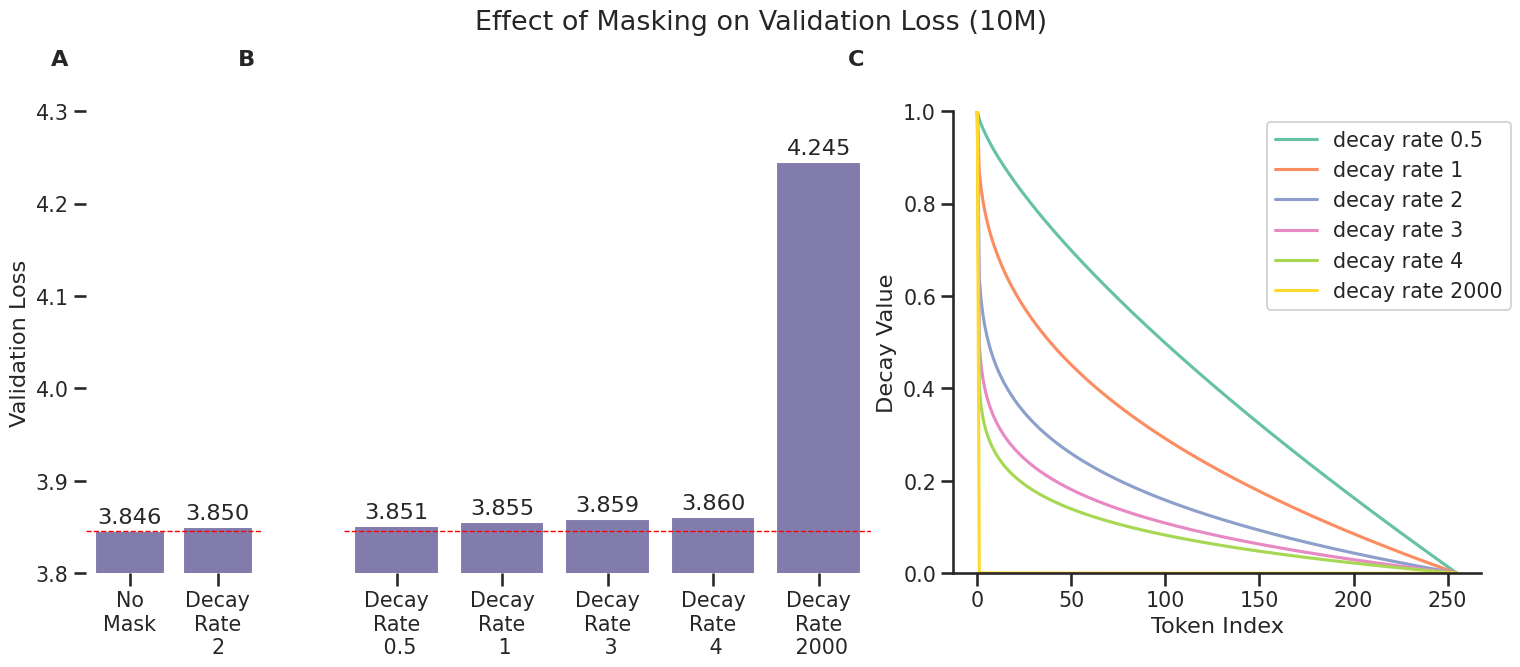

In [6]:
#Figure 4 from thesis (Effect of masking on performance for cross entropy loss)


def ret_chart_3(fig, axr, option_1=True):
    def get_decay_weight_matrix( n, decay_length, decay_factor=None, decay_type=None, decay_echoic_memory=1):
        
        """
        Get a decay weight matrix for a given context window size n.
        :param n: Context window size for the decay matrix
        :param decay_length: Actual length over which decay happens (usually is supposed to be equal to or greater than n) 
        :param decay_factor: Decay factor for the decay matrix, analogous to weight of the decay
        :param decay_type: Type of decay to apply to the matrix #linear, exponential, inverse_sigmoid, custom_logistic
        :param decay_echoic_memory: Echoic memory for the decay matrix, first n values where "effect of decay" is not applied, where memory is supposedly perfect
        :return: 
        """    
    
        if decay_type == 'linear':
            decay_length = decay_length - decay_echoic_memory+1
            decay_values = torch.linspace(1, 0, decay_length)
            decay_values = torch.cat((torch.ones(decay_echoic_memory-1), decay_values))
            decay_length = decay_length+decay_echoic_memory-1
            if decay_length != n:
                assert decay_length > n  #n is context window size and ideally we want decay length to be larger because we are going to cut it off
                decay_values = decay_values[:n] #Cut off the decay values to the context window size

        elif decay_type == 'exponential':
            decay_length = decay_length - decay_echoic_memory + 1
            nums = torch.linspace(0, 1, decay_length)
            decay_values = torch.exp(-nums * decay_factor)
            decay_values = torch.cat((torch.ones(decay_echoic_memory-1), decay_values))
            decay_length = decay_length+decay_echoic_memory-1
            if decay_length != n:
                assert decay_length > n
                decay_values = decay_values[:n]
    
        elif decay_type == "inverse_sigmoid":
            decay_length = decay_length - decay_echoic_memory + 1 
            nums = torch.linspace(10, -10, decay_length) #assuming hardcoded range between 10 and -10 for now
            decay_values = 1/(1+torch.exp(-decay_factor*nums))
            decay_values = torch.cat((torch.ones(decay_echoic_memory-1), decay_values))
            decay_length = decay_length+decay_echoic_memory-1

            if decay_length != n:
                assert decay_length > n
                decay_values = decay_values[:n]
        
        elif decay_type == "logarithmic":
            decay_length = decay_length - decay_echoic_memory + 1
            nums = torch.linspace(0, 1, decay_length)   
            decay_values = 1-torch.pow(nums,np.e*decay_factor)
            decay_values = torch.cat((torch.ones(decay_echoic_memory-1), decay_values))
            decay_length = decay_length+decay_echoic_memory-1
            if decay_length != n:
                assert decay_length > n
                decay_values = decay_values[:n]
        
        elif decay_type == "exponential_2":
            decay_length = decay_length - decay_echoic_memory + 1
            nums = torch.linspace(0, 1, decay_length)
            decay_values = 1 - torch.pow(nums, 1/(np.e*decay_factor))
            decay_values = torch.cat((torch.ones(decay_echoic_memory-1), decay_values))
            decay_length = decay_length+decay_echoic_memory-1
            if decay_length != n:
                assert decay_length > n
                decay_values = decay_values[:n]
                
                
        elif decay_type == "custom_logistic":
            A = 0  # Lower asymptote
            K = 1  # Upper asymptote
            B = 0.8  # Growth rate
            Q = 125  # Related to value at x=0
            nu = 4  # Shape parameter
            M = 4  # Inflection point (time of max growth)
            
            decay_length = decay_length - decay_echoic_memory + 1
            x = torch.linspace(-10, 14.5, decay_length)
            decay_values = A + (K - A) / (1 + Q * torch.exp(-B * (x - M))) ** (1 / nu)
            decay_values = torch.flip(decay_values, [0])
            decay_values = torch.cat((torch.ones(decay_echoic_memory-1), decay_values))
            decay_length = decay_length+decay_echoic_memory-1
            if decay_length != n:
                assert decay_length > n
                decay_values = decay_values[:n]
    
        # Apply the decay values to the lower triangle
    
        indices = torch.arange(n)[:, None] - torch.arange(n)
        lower_triangle = torch.tril(decay_values[indices])
        lower_triangle = lower_triangle.float()
    
        return lower_triangle
    if option_1:
        for i in [1]:
            for dt in ['exponential_2']:
                color_map = sns.color_palette("Set2", 6)
                #color_map = sns.color_palette("Purples_r", 6)
                decay_rate_list = [0.5, 1, 2, 3, 4, 2000]
                for j in decay_rate_list:
                    d_vals = get_decay_weight_matrix(256, 256, decay_factor=j, decay_type=dt, decay_echoic_memory=i)
                    plot_vals = d_vals[-1]
                    plot_vals = plot_vals.flip([0])
                    #Annotate 5th value in each curve of the plot using arrow 
                    #axr.annotate(f'{plot_vals[5]:.3f}', (8, plot_vals[5]-0.01) ) 
                    #axr.plot(5, plot_vals[5], ".")
                    #axr.axvline(x=5, color='black', linestyle='--')
                    sns.lineplot(plot_vals, label=f"Decay rate {j}", ax=axr, color=color_map[decay_rate_list.index(j)])
            axr.set_xlabel('Index')
            axr.set_ylabel('Decay Value')
            #axr.set_xticks(axr.get_xticks().tolist()[2:-1])
            axr.set_ylim(0, 1)
            #axr.set_color_cycle(palette="Purples_r")
            
            axr.legend(axr.get_legend_handles_labels()[0], ["decay rate 0.5", "decay rate 1", "decay rate 2", "decay rate 3", "decay rate 4", "decay rate 2000"], bbox_to_anchor=(0.575, 1), loc='upper left')
    else:
        annotate_x = [6,6,6,6]
        annotate_y = [0.01, 0.035, 0.06, 0.075]
        for dt, decay_rate_list in [("linear", 1), ("logarithmic", 0.5), ("logarithmic", 1), ("logarithmic", 2)]:
            d_vals = get_decay_weight_matrix(256, 256, decay_factor=decay_rate_list, decay_type=dt, decay_echoic_memory=1)
            plot_vals = d_vals[-1]
            plot_vals = plot_vals.flip([0])
            
            axr.annotate(f'{plot_vals[5]:.3f}', (annotate_x.pop(), plot_vals[5]-annotate_y.pop()) )
            axr.plot(5, plot_vals[5], ".")
            axr.axvline(x=5, color='black', linestyle='--')
            sns.lineplot(plot_vals, label=f"{dt} Decay Rate {decay_rate_list}", ax=axr)
            
        axr.set_xlabel('Index')
        axr.set_ylabel('Decay Value')
        axr.set_xticks(axr.get_xticks().tolist()[2:-1]+[5])
        axr.set_ylim(0, 1)
        axr.legend(axr.get_legend_handles_labels()[0], ["Linear", "Logarithmic Decay Rate 0.5", "Logarithmic Decay Rate 1", "Logarithmic Decay Rate 2"],  loc='lower left')
        
    return axr


plot_loss2 = run_data[(run_data["curriculum_learning"]==False) & (run_data["dataset"] == "babylm_full_bpe_8k") & (run_data["echoic_memory"]==1) &
                      (~run_data["mask_type"].isin(["exponential", "sigmoid"])) & (run_data["n_layer"]==6) & (run_data["batch_size"]==32) & (run_data["num_iterations"]==44000)
                      ][["run_id", "output_folder_name", "mask_type", "mask_decay_rate", "echoic_memory" ]].assign(mask_type=lambda x: pd.Categorical(x["mask_type"], categories=["Non", "linear", "exponential_new", "logarithmic", "sigmoid"], ordered=True)).sort_values(by=["mask_type", "mask_decay_rate"])
plot_loss2 = plot_loss2[~plot_loss2["run_id"].isin([5734459, 5496427, 6617787])]
plot_loss2 = plot_loss2.merge(loss_data, on="run_id")

#Convert string to %g for better display
plot_loss2["x_label"] = plot_loss2["mask_type"].replace({"linear": "Linear",
                                                         "logarithmic": "Logarithmic",
                                                         "Non": "No Mask",
                                                         "sigmoid": "Sigmoid",
                                                         "exponential_new": "Exponential",
                                                         }).astype(str) + " " + plot_loss2["mask_decay_rate"].astype(str).replace("\.0", "", regex=True).replace("0", "")

plot_loss2_b = plot_loss2[(plot_loss2["mask_type"] == "exponential_new") & (plot_loss2["mask_decay_rate"] != 2)]
plot_loss2["x_label"] = (plot_loss2.x_label.apply(lambda x: x.rstrip("")).map({
    "No Mask ": "No\nMask",
    "Linear ": "Linear",
    "Exponential 0.5": "Weak\nExponential",
    "Exponential 1": "Intermediate\nExponential",
    "Exponential 2": "Decay\nRate\n2",
    "Logarithmic 0.5": "Weak\nLogarithmic",
    "Logarithmic 1": "Intermediate\nLogarithmic",
    "Logarithmic 2": "Strong\nLogarithmic",
}))
plot_loss2_a = plot_loss2[plot_loss2["x_label"].isin(["Decay\nRate\n2"])]
plot_loss2_a = plot_loss2[plot_loss2["x_label"].isin(["No\nMask", "Decay\nRate\n2"])]


with sns.axes_style("ticks"), sns.plotting_context("talk", font_scale=.9):

    #rcParams.update(params_two_col) 
    fig, ax = plt.subplots(1, 3, width_ratios=[1, 3,3])
    fig.set_size_inches(18, 6)
    sns.barplot(data=plot_loss2_a, x="x_label", y="val_loss", ax=ax[0], color = sns.color_palette("Purples_r", as_cmap=True)(0.35))
    ax[0].set_ylim(3.8, 4.3)
    ax[1].set_ylim(3.8, 4.3)
    color_mapper = {
                        0.5: 'tab:olive',
                        1: 'tab:green',
                        2: 'tab:orange',
                        3: 'tab:red',
                        4: 'tab:purple',
                        2000: 'tab:gray'
                    }

        

    sns.barplot(data=plot_loss2_b, x="x_label", y="val_loss", ax=ax[1], color = sns.color_palette("Purples_r", as_cmap=True)(0.35))

    ax[0].set_xticklabels(labels = ax[0].get_xticklabels())
    ax[1].set_xticklabels([x.get_text().replace("Exponential", "Decay\nRate\n") for x in ax[1].get_xticklabels()])

    ax[0].axhline(y=pd.Series(plot_loss2_a[plot_loss2_a["x_label"] == "No\nMask"]['val_loss']).values[0], color='red', linestyle='--', lw=1)

    ax[1].axhline(y=pd.Series(plot_loss2_a[plot_loss2_a["x_label"] == "No\nMask"]['val_loss']).values[0], color='red', linestyle='--', lw=1)
    ax[0].set_ylabel("Validation Loss")
    ax[1].set_ylabel("")
    ax[1].set_yticks([])
    ax[0].set_xlabel("")
    ax[1].set_xlabel("")

    for p in ax[0].patches:
        ax[0].annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 10), textcoords='offset points')
    for p in ax[1].patches:
        ax[1].annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 10), textcoords='offset points')

    ax[2] = ret_chart_3(fig, ax[2])

    ax[2].set_ylabel("Decay Value")
    ax[2].set_xlabel("Token Index")
    for n, axs in enumerate(ax.flat):
        axs.text(-0.2, 1.1, string.ascii_uppercase[n], transform=axs.transAxes, weight='bold')

    sns.despine(bottom=True, left=True, ax=ax[0])
    sns.despine(bottom=True, left=True, ax=ax[1])
    sns.despine(ax=ax[2])
    #save_matplot_fig(fig, "val_error_mask_no_mask_fig1_hq_v3", dpi=2000)
    #save_matplot_fig(fig, "val_error_mask_no_mask_fig1_hq_v4.pdf", dpi=2000)

    #save_matplot_fig(fig, "Fig1_val_error_masks.pdf", dpi=3000)

    fig.suptitle("Effect of Masking on Validation Loss (10M)", y = 1.05)
    #save_matplot_fig(fig, "Figure_4.png", dpi=1000)
    #save_matplot_fig(fig, "Figure_4.pdf", dpi=3000)

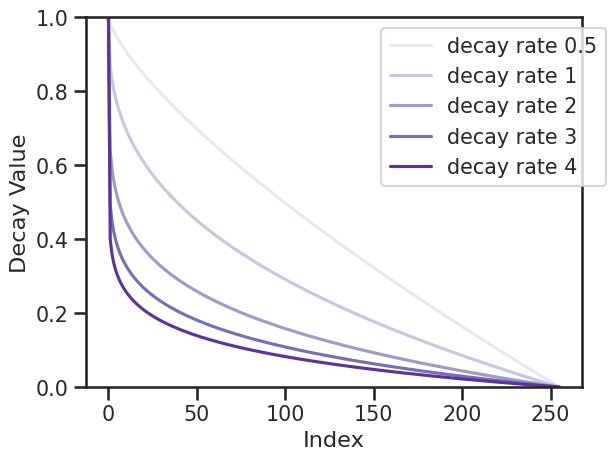

In [15]:
#Block to reproduce sub figure C but with single color but sequential color map

def ret_chart_4(fig, axr, option_1=True):
    def get_decay_weight_matrix( n, decay_length, decay_factor=None, decay_type=None, decay_echoic_memory=1):
        
        """
        Get a decay weight matrix for a given context window size n.
        :param n: Context window size for the decay matrix
        :param decay_length: Actual length over which decay happens (usually is supposed to be equal to or greater than n) 
        :param decay_factor: Decay factor for the decay matrix, analogous to weight of the decay
        :param decay_type: Type of decay to apply to the matrix #linear, exponential, inverse_sigmoid, custom_logistic
        :param decay_echoic_memory: Echoic memory for the decay matrix, first n values where "effect of decay" is not applied, where memory is supposedly perfect
        :return: 
        """    
    
        if decay_type == 'linear':
            decay_length = decay_length - decay_echoic_memory+1
            decay_values = torch.linspace(1, 0, decay_length)
            decay_values = torch.cat((torch.ones(decay_echoic_memory-1), decay_values))
            decay_length = decay_length+decay_echoic_memory-1
            if decay_length != n:
                assert decay_length > n  #n is context window size and ideally we want decay length to be larger because we are going to cut it off
                decay_values = decay_values[:n] #Cut off the decay values to the context window size

        elif decay_type == 'exponential':
            decay_length = decay_length - decay_echoic_memory + 1
            nums = torch.linspace(0, 1, decay_length)
            decay_values = torch.exp(-nums * decay_factor)
            decay_values = torch.cat((torch.ones(decay_echoic_memory-1), decay_values))
            decay_length = decay_length+decay_echoic_memory-1
            if decay_length != n:
                assert decay_length > n
                decay_values = decay_values[:n]
    
        elif decay_type == "inverse_sigmoid":
            decay_length = decay_length - decay_echoic_memory + 1 
            nums = torch.linspace(10, -10, decay_length) #assuming hardcoded range between 10 and -10 for now
            decay_values = 1/(1+torch.exp(-decay_factor*nums))
            decay_values = torch.cat((torch.ones(decay_echoic_memory-1), decay_values))
            decay_length = decay_length+decay_echoic_memory-1

            if decay_length != n:
                assert decay_length > n
                decay_values = decay_values[:n]
        
        elif decay_type == "logarithmic":
            decay_length = decay_length - decay_echoic_memory + 1
            nums = torch.linspace(0, 1, decay_length)   
            decay_values = 1-torch.pow(nums,np.e*decay_factor)
            decay_values = torch.cat((torch.ones(decay_echoic_memory-1), decay_values))
            decay_length = decay_length+decay_echoic_memory-1
            if decay_length != n:
                assert decay_length > n
                decay_values = decay_values[:n]
        
        elif decay_type == "exponential_2":
            decay_length = decay_length - decay_echoic_memory + 1
            nums = torch.linspace(0, 1, decay_length)
            decay_values = 1 - torch.pow(nums, 1/(np.e*decay_factor))
            decay_values = torch.cat((torch.ones(decay_echoic_memory-1), decay_values))
            decay_length = decay_length+decay_echoic_memory-1
            if decay_length != n:
                assert decay_length > n
                decay_values = decay_values[:n]
                
                
        elif decay_type == "custom_logistic":
            A = 0  # Lower asymptote
            K = 1  # Upper asymptote
            B = 0.8  # Growth rate
            Q = 125  # Related to value at x=0
            nu = 4  # Shape parameter
            M = 4  # Inflection point (time of max growth)
            
            decay_length = decay_length - decay_echoic_memory + 1
            x = torch.linspace(-10, 14.5, decay_length)
            decay_values = A + (K - A) / (1 + Q * torch.exp(-B * (x - M))) ** (1 / nu)
            decay_values = torch.flip(decay_values, [0])
            decay_values = torch.cat((torch.ones(decay_echoic_memory-1), decay_values))
            decay_length = decay_length+decay_echoic_memory-1
            if decay_length != n:
                assert decay_length > n
                decay_values = decay_values[:n]
    
        # Apply the decay values to the lower triangle
    
        indices = torch.arange(n)[:, None] - torch.arange(n)
        lower_triangle = torch.tril(decay_values[indices])
        lower_triangle = lower_triangle.float()
    
        return lower_triangle
    if option_1:
        for i in [1]:
            for dt in ['exponential_2']:
                #color_map = sns.color_palette("Set2", 6)
                color_map = sns.color_palette("Purples_r", 5)
                color_map = color_map[::-1]
                #color_map = sns.color_palette("Purples_r", 6)
                decay_rate_list = [0.5, 1, 2, 3, 4]
                for j in decay_rate_list:
                    d_vals = get_decay_weight_matrix(256, 256, decay_factor=j, decay_type=dt, decay_echoic_memory=i)
                    plot_vals = d_vals[-1]
                    plot_vals = plot_vals.flip([0])
                    #Annotate 5th value in each curve of the plot using arrow 
                    #axr.annotate(f'{plot_vals[5]:.3f}', (8, plot_vals[5]-0.01) ) 
                    #axr.plot(5, plot_vals[5], ".")
                    #axr.axvline(x=5, color='black', linestyle='--')
                    sns.lineplot(plot_vals, label=f"Decay rate {j}", ax=axr, color=color_map[decay_rate_list.index(j)])
            axr.set_xlabel('Index')
            axr.set_ylabel('Decay Value')
            #axr.set_xticks(axr.get_xticks().tolist()[2:-1])
            axr.set_ylim(0, 1)
            #axr.set_color_cycle(palette="Purples_r")
            
            axr.legend(axr.get_legend_handles_labels()[0], ["decay rate 0.5", "decay rate 1", "decay rate 2", "decay rate 3", "decay rate 4", "decay rate 2000"], bbox_to_anchor=(0.575, 1), loc='upper left')
    else:
        annotate_x = [6,6,6,6]
        annotate_y = [0.01, 0.035, 0.06, 0.075]
        for dt, decay_rate_list in [("linear", 1), ("logarithmic", 0.5), ("logarithmic", 1), ("logarithmic", 2)]:
            d_vals = get_decay_weight_matrix(256, 256, decay_factor=decay_rate_list, decay_type=dt, decay_echoic_memory=1)
            plot_vals = d_vals[-1]
            plot_vals = plot_vals.flip([0])
            
            axr.annotate(f'{plot_vals[5]:.3f}', (annotate_x.pop(), plot_vals[5]-annotate_y.pop()) )
            axr.plot(5, plot_vals[5], ".")
            axr.axvline(x=5, color='black', linestyle='--')
            sns.lineplot(plot_vals, label=f"{dt} Decay Rate {decay_rate_list}", ax=axr)
            
        axr.set_xlabel('Index')
        axr.set_ylabel('Decay Value')
        axr.set_xticks(axr.get_xticks().tolist()[2:-1]+[5])
        axr.set_ylim(0, 1)
        axr.legend(axr.get_legend_handles_labels()[0], ["Linear", "Logarithmic Decay Rate 0.5", "Logarithmic Decay Rate 1", "Logarithmic Decay Rate 2"],  loc='lower left')
        
    return axr


with sns.axes_style("ticks"), sns.plotting_context("talk", font_scale=.9):

    fig, ax = plt.subplots(1, 1)

    ax  = ret_chart_4(fig, ax)




In [253]:
seed_df = run_data_unfiltered[run_data_unfiltered["mask_type"].isin(["exponential_new", "Non"]) & (run_data_unfiltered["curriculum_learning"]== False) & (run_data_unfiltered["dataset"] == "babylm_full_bpe_8k") & (run_data_unfiltered["n_layer"]==6) & (run_data_unfiltered["mask_decay_rate"].isin([0, 2, 2000]))
& (run_data_unfiltered["batch_size"]==32) & (run_data_unfiltered["num_iterations"]==44000)                          
                              ].reset_index(drop=True)

#Filter out run_id = 5496427, duplicate run_id for no mask 1337 seed
seed_df = seed_df[~seed_df["run_id"].isin([5496427])].reset_index(drop=True)
seed_df["Mask Type"] = seed_df["mask_type"].replace({"Non": "No Mask", "exponential_new": "Power Law"})
seed_df["condition"] = (seed_df["mask_type"].replace({"Non": "nomask", "exponential_new": "ee"}) + seed_df["mask_decay_rate"].astype(int).astype(str).str.zfill(3).
replace("000","") + "_EM" + seed_df["echoic_memory"].astype(str).str.zfill(2))


# seed_df_100M = run_data_unfiltered[run_data_unfiltered["mask_type"].isin(["exponential_new", "Non"]) & (run_data_unfiltered["curriculum_learning"]== False) & (run_data_unfiltered["dataset"] == "babylm_full_bpe_100M_8k") & (run_data_unfiltered["n_layer"]==6) & (run_data_unfiltered["mask_decay_rate"].isin([0, 2])) & (run_data_unfiltered["batch_size"]==32) & (run_data_unfiltered["num_iterations"]==44000)].reset_index(drop=True)



# seed_df_100M = seed_df_100M[~seed_df_100M["run_id"].isin([8456913])].reset_index(drop=True)
# seed_df_100M["Mask Type"] = seed_df_100M["mask_type"].replace({"Non": "No Mask", "exponential_new": "Power Law"})

# seed_df_100M["condition"] = (seed_df_100M["mask_type"].replace({"Non": "nomask", "exponential_new": "ee"}) + seed_df_100M["mask_decay_rate"].astype(int).astype(str).str.zfill(3).replace("000","")+ "_EM" + seed_df_100M["echoic_memory"].astype(str).str.zfill(2))

#seed_df
print(seed_df["condition"].value_counts())
print(seed_df.groupby(["Mask Type", "mask_decay_rate", "echoic_memory"]).size())
print(seed_df_100M.groupby(["mask_decay_rate", "echoic_memory"]).size())

condition
ee002_EM05     10
ee002_EM10     10
ee002_EM01     10
ee2000_EM01    10
ee2000_EM05    10
ee2000_EM10    10
nomask_EM01    10
Name: count, dtype: int64
Mask Type  mask_decay_rate  echoic_memory
No Mask    0.0              1                10
Power Law  2.0              1                10
                            5                10
                            10               10
           2000.0           1                10
                            5                10
                            10               10
dtype: int64
mask_decay_rate  echoic_memory
0.0              1                10
2.0              10               10
dtype: int64


condition
No\nMask    10
Mask        10
Name: count, dtype: int64
Comparing Mask and No
Mask


/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])


{'mean                    ': -0.013513422012329145, '95%_CI around mean      ': (-0.017659356594086007, -0.00898563385009757), 'bootstrap-t-test p_value': 'p=0.0012'}
Old y, h 3.875 0.0015
Y lim values (3.8, 3.9)
New y, h 3.8899999999999997 0.0030000000000000027
[1.5 3. ]


/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])


Comparing Mask and No
Mask
{'mean                    ': 1.039780616572982, '95%_CI around mean      ': (0.5161924435294771, 1.544281033669681), 'bootstrap-t-test p_value': 'p=0.0086'}
Old y, h 72 0.25
Y lim values (65.0, 75.0)
New y, h 74.0 0.3
[1.5 3. ]


/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])


Comparing Mask and No
Mask
{'mean                    ': -74.40259675537236, '95%_CI around mean      ': (-112.11606486887436, -36.135559619224196), 'bootstrap-t-test p_value': 'p=0.0104'}
Old y, h 1850 25
Y lim values (1000.0, 2000.0)
New y, h 1900.0 30.0


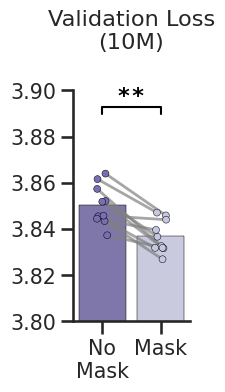

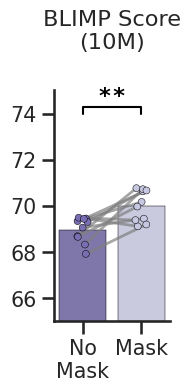

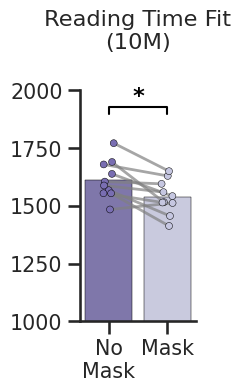

In [293]:

# Best masking figures for 10M dataset - Filter for 10M dataset for no mask and mask decay rate 2 EM 10, Plot for validation loss and BLIMP scores and reading time fit

seed_df_10M = run_data_unfiltered[
    (run_data_unfiltered["curriculum_learning"] == False) & (run_data_unfiltered["dataset"] == "babylm_full_bpe_8k") & 
    (run_data_unfiltered["n_layer"] == 6) & (run_data_unfiltered["batch_size"] == 32) & (run_data_unfiltered["num_iterations"] == 44000)
    & (((run_data_unfiltered["mask_type"].isin(["Non"]))  & (run_data_unfiltered["run_id"] != 5496427)) (do you have vector format?) - In Canva

# * Figure 4 from thesis (Effect of masking on performance for cross entropy loss)
# * Figure 5 from thesis (

seed_df_10M["condition"] = seed_df_10M["mask_type"].apply(lambda x: "Mask" if x != "Non" else "No\nMask")
seed_df_10M = seed_df_10M.sort_values(by=["seed", "condition"]).reset_index(drop=True)
seed_df_10M["condition"] = pd.Categorical(seed_df_10M["condition"], categories=["No\nMask", "Mask"], ordered=True)
print(seed_df_10M["condition"].value_counts())

seed_df_10M = seed_df_10M.merge(loss_data[['run_id', 'val_loss', 'train_loss']], on="run_id", how="left")
seed_df_10M = seed_df_10M.merge(blimp_data[["run_id", "blimp_avg"]], on="run_id", how="left")
seed_df_10M = seed_df_10M.merge(reading_time_fit_df_osh[["ModelID", "Delta Log-Likelihood", "Data Size"]].add_suffix("_osh"), how="left", left_on="run_id", right_on="ModelID_osh",).drop(columns=["ModelID_osh"])
seed_df_10M["delta_log_likelihood_avg_osh"] = seed_df_10M["Delta Log-Likelihood_osh"] / seed_df_10M["Data Size_osh"]
seed_df_10M = seed_df_10M.merge(reading_time_fit_df_wil[["ModelID", "Delta Log-Likelihood", "Data Size"]].add_suffix("_wil"), how="left", left_on="run_id", right_on="ModelID_wil",).drop(columns=["ModelID_wil"])
seed_df_10M["delta_log_likelihood_avg_wil"] = seed_df_10M["Delta Log-Likelihood_wil"] / seed_df_10M["Data Size_wil"]
seed_df_10M = seed_df_10M.merge(reading_time_fit_df_wil2[["ModelID", "Delta Log-Likelihood", "Data Size"]].add_suffix("_wil2"), how="left", left_on="run_id", right_on="ModelID_wil2",).drop(columns=["ModelID_wil2"])
seed_df_10M["delta_log_likelihood_avg_wil2"] = seed_df_10M["Delta Log-Likelihood_wil2"] / seed_df_10M["Data Size_wil2"]


#Plot validation loss, BLIMP scores and reading time fit for 10M dataset

with sns.axes_style("ticks"), sns.plotting_context("talk", font_scale=.9):
    #plt.figure(figsize=(1.5,3))
    fig, ax = plt.subplots(1, 1, figsize=(1.5,3))
    sns.stripplot(data=seed_df_10M, x="condition", y="val_loss", hue = "condition", palette="Purples_r", edgecolor='k', linewidth=0.35, ax=ax)
    connect_dots(ax, alpha=0.7)
    sns.barplot(data=seed_df_10M, x="condition", y="val_loss", hue="condition", palette="Purples_r", ax=ax, edgecolor='k', linewidth=0.35, errorbar=None, alpha=1)
    
    ax.set_ylim(3.8, 3.9)
    #ax.set_ylabel("Validation Loss")
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_title("Validation Loss\n(10M)", pad=30)
    annotate_given_colid(ax, 1, 0, seed_df_10M, 3.875, 0.0015, "val_loss")
    sns.despine()
    print(fig.get_size_inches())
    save_matplot_fig(fig, "10M_pairwise_val_loss.png", dpi=1000, folders_path="10M_pairwise_sep")
    save_matplot_fig(fig, "10M_pairwise_val_loss.pdf", dpi=3000, folders_path="10M_pairwise_sep")

with sns.axes_style("ticks"), sns.plotting_context("talk", font_scale=.9):
    fig, ax = plt.subplots(1, 1, figsize=(1.5,3))
    sns.stripplot(data=seed_df_10M, x="condition", y="blimp_avg", hue = "condition", palette="Purples_r", edgecolor='k', linewidth=0.35, ax=ax)
    connect_dots(ax, alpha=0.7) (do you have vector format?) - In Canva

# * Figure 4 from thesis (Effect of masking on performance for cross entropy loss)
# * Figure 5 from thesis (
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("BLIMP Score\n(10M)", pad=30)
    #Set number of y ticks as 5
    ax.yaxis.set_major_locator(plt.MaxNLocator(5))    
    annotate_given_colid(ax, 1, 0, seed_df_10M, 72, 0.25, "blimp_avg")
    sns.despine()
    print(fig.get_size_inches())
    save_matplot_fig(fig, "10M_pairwise_blimp_score.png", dpi=1000, folders_path="10M_pairwise_sep")
    save_matplot_fig(fig, "10M_pairwise_blimp_score.pdf", dpi=3000, folders_path="10M_pairwise_sep")
#seed_df_10M

with sns.axes_style("ticks"), sns.plotting_context("talk", font_scale=.9):
    #plt.figure(figsize=(1.5,3))
    fig, ax = plt.subplots(1, 1, figsize=(1.5,3))   
    sns.stripplot(data=seed_df_10M, x="condition", y="Delta Log-Likelihood_osh", hue = "condition", palette="Purples_r", edgecolor='k', linewidth=0.35, ax=ax) (do you have vector format?) - In Canva

# * Figure 4 from thesis (Effect of masking on performance for cross entropy loss)
# * Figure 5 from thesis (
    connect_dots(ax, alpha=0.7)
    sns.barplot(data=seed_df_10M, x="condition", y="Delta Log-Likelihood_osh", hue="condition", palette="Purples_r", ax=ax, edgecolor='k', linewidth=0.35, errorbar=None, alpha=1)

    ax.set_ylim(1000,2000)
    ax.yaxis.set_major_locator(plt.MaxNLocator(4))
    #ax.set_ylabel("$\Delta$ Log-Likelihood")
    
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("Reading Time Fit\n(10M)", pad=30)
    annotate_given_colid(ax, 1, 0, seed_df_10M, 1850, 25, "Delta Log-Likelihood_osh") (do you have vector format?) - In Canva

# * Figure 4 from thesis (Effect of masking on performance for cross entropy loss)
# * Figure 5 from thesis (
    save_matplot_fig(fig, "10M_pairwise_reading_time_fit.png", dpi=1000, folders_path="10M_pairwise_sep")
    save_matplot_fig(fig, "10M_pairwise_reading_time_fit.pdf", dpi=3000, folders_path="10M_pairwise_sep")




condition
No\nMask    10
Mask        10
Name: count, dtype: int64
Comparing Mask and No
Mask


/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


{'mean                    ': -0.013513422012329145, '95%_CI around mean      ': (-0.017659356594086007, -0.00898563385009757), 'bootstrap-t-test p_value': 'p=0.0012'}
Old y, h 3.875 0.0015
Y lim values (3.8, 3.9)
New y, h 3.8899999999999997 0.0030000000000000027
Comparing Mask and No
Mask


/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


{'mean                    ': 1.039780616572982, '95%_CI around mean      ': (0.5161924435294771, 1.544281033669681), 'bootstrap-t-test p_value': 'p=0.0086'}
Old y, h 73 0.25
Y lim values (65.0, 75.0)
New y, h 74.0 0.3
Comparing Mask and No
Mask


/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


{'mean                    ': -74.40259675537236, '95%_CI around mean      ': (-112.11606486887436, -36.135559619224196), 'bootstrap-t-test p_value': 'p=0.0104'}
Old y, h 1850 25
Y lim values (1000.0, 2000.0)
New y, h 1900.0 30.0


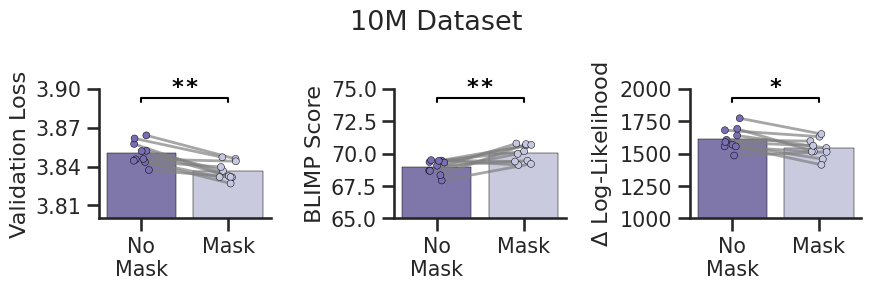

In [ ]:
# Best masking figures for 10M dataset - Filter for 10M dataset for no mask and mask decay rate 2 EM 10, Plot for validation loss and BLIMP scores and reading time fit

seed_df_10M = run_data_unfiltered[
    (run_data_unfiltered["curriculum_learning"] == False) & (run_data_unfiltered["dataset"] == "babylm_full_bpe_8k") & 
    (run_data_unfiltered["n_layer"] == 6) & (run_data_unfiltered["batch_size"] == 32) & (run_data_unfiltered["num_iterations"] == 44000)
    & (((run_data_unfiltered["mask_type"].isin(["Non"]))  & (run_data_unfiltered["run_id"] != 5496427))
        | ((run_data_unfiltered["mask_type"].isin(["exponential_new"])) & (run_data_unfiltered["mask_decay_rate"] == 2) & (run_data_unfiltered["echoic_memory"] == 10)))
][["run_id", "output_folder_name", "n_layer", "n_head", "block_size", "n_embd", "batch_size", "learning_rate", "mask_type", "mask_decay_rate", "echoic_memory", "dataset", "seed"]].reset_index(drop=True)

seed_df_10M["condition"] = seed_df_10M["mask_type"].apply(lambda x: "Mask" if x != "Non" else "No\nMask")
seed_df_10M = seed_df_10M.sort_values(by=["seed", "condition"]).reset_index(drop=True)
seed_df_10M["condition"] = pd.Categorical(seed_df_10M["condition"], categories=["No\nMask", "Mask"], ordered=True)
print(seed_df_10M["condition"].value_counts())

seed_df_10M = seed_df_10M.merge(loss_data[['run_id', 'val_loss', 'train_loss']], on="run_id", how="left")
seed_df_10M = seed_df_10M.merge(blimp_data[["run_id", "blimp_avg"]], on="run_id", how="left")
seed_df_10M = seed_df_10M.merge(reading_time_fit_df_osh[["ModelID", "Delta Log-Likelihood", "Data Size"]].add_suffix("_osh"), how="left", left_on="run_id", right_on="ModelID_osh",).drop(columns=["ModelID_osh"])
seed_df_10M["delta_log_likelihood_avg_osh"] = seed_df_10M["Delta Log-Likelihood_osh"] / seed_df_10M["Data Size_osh"]
seed_df_10M = seed_df_10M.merge(reading_time_fit_df_wil[["ModelID", "Delta Log-Likelihood", "Data Size"]].add_suffix("_wil"), how="left", left_on="run_id", right_on="ModelID_wil",).drop(columns=["ModelID_wil"])
seed_df_10M["delta_log_likelihood_avg_wil"] = seed_df_10M["Delta Log-Likelihood_wil"] / seed_df_10M["Data Size_wil"]
seed_df_10M = seed_df_10M.merge(reading_time_fit_df_wil2[["ModelID", "Delta Log-Likelihood", "Data Size"]].add_suffix("_wil2"), how="left", left_on="run_id", right_on="ModelID_wil2",).drop(columns=["ModelID_wil2"])
seed_df_10M["delta_log_likelihood_avg_wil2"] = seed_df_10M["Delta Log-Likelihood_wil2"] / seed_df_10M["Data Size_wil2"]

# Plot validation loss, BLIMP scores and reading time fit for 10M dataset
with sns.axes_style("ticks"), sns.plotting_context("talk", font_scale=.9):
    fig, axs = plt.subplots(1, 3, figsize=(9, 3))

    # Validation Loss
    ax = sns.stripplot(data=seed_df_10M, x="condition", y="val_loss", hue="condition", palette="Purples_r", edgecolor='k', linewidth=0.35, ax=axs[0])
    connect_dots(ax, alpha=0.7)
    sns.barplot(data=seed_df_10M, x="condition", y="val_loss", hue="condition", palette="Purples_r", ax=axs[0], edgecolor='k', linewidth=0.35, errorbar=None, alpha=1)
    axs[0].set_ylim(3.8, 3.9)
    axs[0].set_ylabel("Validation Loss")
    axs[0].set_xlabel("")
    axs[0].yaxis.set_major_locator(plt.MaxNLocator(4))
    annotate_given_colid(axs[0], 1, 0, seed_df_10M, 3.875, 0.0015, "val_loss")
    axs[0].legend().remove()
    sns.despine(ax=axs[0])

    # BLIMP Score
    ax = sns.stripplot(data=seed_df_10M, x="condition", y="blimp_avg", hue="condition", palette="Purples_r", edgecolor='k', linewidth=0.35, ax=axs[1])
    connect_dots(ax, alpha=0.7)
    sns.barplot(data=seed_df_10M, x="condition", y="blimp_avg", hue="condition", palette="Purples_r", ax=axs[1], edgecolor='k', linewidth=0.35, errorbar=None, alpha=1)
    axs[1].set_ylim(65, 75)
    axs[1].set_ylabel("BLIMP Score")
    axs[1].set_xlabel("")
    axs[1].yaxis.set_major_locator(plt.MaxNLocator(4))
    annotate_given_colid(axs[1], 1, 0, seed_df_10M, 73, 0.25, "blimp_avg")
    axs[1].legend().remove()
    sns.despine(ax=axs[1])

    # Reading Time Fit (do you have vector format?) - In Canva

# * Figure 4 from thesis (Effect of masking on performance for cross entropy loss)
# * Figure 5 from thesis (
    ax = sns.stripplot(data=seed_df_10M, x="condition", y="Delta Log-Likelihood_osh", hue="condition", palette="Purples_r", edgecolor='k', linewidth=0.35, ax=axs[2])
    connect_dots(ax, alpha=0.7)
    sns.barplot(data=seed_df_10M, x="condition", y="Delta Log-Likelihood_osh", hue="condition", palette="Purples_r", ax=axs[2], edgecolor='k', linewidth=0.35, errorbar=None, alpha=1)
    axs[2].set_ylim(1000, 2000)
    axs[2].yaxis.set_major_locator(plt.MaxNLocator(4))
    axs[2].set_ylabel("$\Delta$ Log-Likelihood")
    axs[2].set_xlabel("")
    annotate_given_colid(axs[2], 1, 0, seed_df_10M, 1850, 25, "Delta Log-Likelihood_osh")
    axs[2].legend().remove()
    sns.despine(ax=axs[2])

    fig.suptitle("10M Dataset")
    fig.tight_layout()
    plt.tight_layout()
    plt.show()


save_matplot_fig(fig, "10M_Pairwise_results_combined.png", dpi=1000)


/tmp/ipykernel_476852/3558331422.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=plot_data, x="condition", y="val_loss",
/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])


Comparing Mask
No EM and No Mask
{'mean                    ': 0.007327985763549849, '95%_CI around mean      ': (0.004357456564903219, 0.01030530214309719), 'bootstrap-t-test p_value': 'p=0.0008'}
Old y, h 3.875 0.002
Y lim values (3.75, 3.94)
New y, h 3.8906 0.0056999999999999985
Comparing Mask
EM 5 and No Mask


/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])
/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(g

{'mean                    ': -0.005926585197448553, '95%_CI around mean      ': (-0.008891927599906915, -0.0027906960248944047), 'bootstrap-t-test p_value': 'p=0.0138'}
Old y, h 3.8825 0.002
Y lim values (3.75, 3.94)
New y, h 3.9114999999999998 0.0056999999999999985
Comparing Mask
EM 10 and No Mask
{'mean                    ': -0.013513422012329145, '95%_CI around mean      ': (-0.017659356594086007, -0.00898563385009757), 'bootstrap-t-test p_value': 'p=0.0012'}
Old y, h 3.89 0.002
Y lim values (3.75, 3.94)
New y, h 3.9324 0.0056999999999999985
        pair_A      pair_B  mean                      \
0  nomask_EM01  ee002_EM01                  0.007328   
1  nomask_EM01  ee002_EM05                 -0.005927   
2  nomask_EM01  ee002_EM10                 -0.013513   

                          95%_CI around mean       bootstrap-t-test p_value  
0      (0.004357456564903219, 0.01030530214309719)                 p=0.0008  
1  (-0.008891927599906915, -0.0027906960248944047)                 p

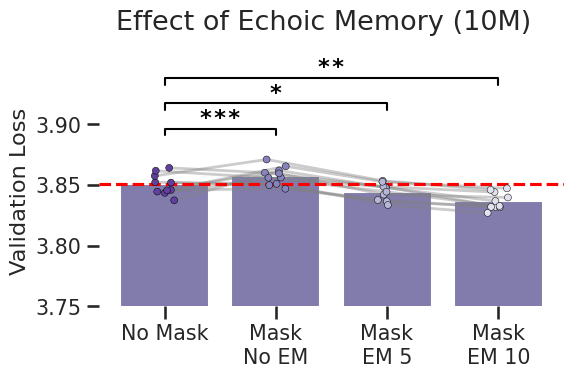

In [263]:
 (do you have vector format?) - In Canva

# * Figure 4 from thesis (Effect of masking on performance for cross entropy loss)
# * Figure 5 from thesis (   "ee2000_EM05": "Extreme\nMask\nEM 5", 
                         "ee2000_EM10": "Extreme\nMask\nEM 10"}

#fig = plt.figure(figsize=(15, 10))
#rcParams.update(params_one_col)
with sns.axes_style("ticks"), sns.plotting_context("talk", font_scale=.9):

    fig, ax = plt.subplots(1, 1, figsize=(6, 3))
    stats_test = []

    row_titles = ["Validation Loss", "Train Loss"]
    plot_data = seed_df.merge(loss_data, on="run_id", how="left")[["seed", "condition", "val_loss"]][seed_df["condition"].isin(["nomask_EM01", "ee002_EM01", "ee002_EM05", "ee002_EM10"])]
    #plot_data = plot_data.sort_values(by="seed").reset_index(drop=True)
    #print(plot_data)
    #Condition Order: No Mask, Exp Mask EM 0, Exp Mask EM 5, Exp Mask EM 10
    plot_data["condition"] = pd.Categorical(plot_data["condition"], categories=["nomask_EM01", "ee002_EM01", "ee002_EM05", "ee002_EM10"], ordered=True)
    plot_data["condition"] = plot_data["condition"].map(condition_triplet_map)
    
    #plot_data = plot_data.sort_values(by="condition").reset_index(drop=True)
    #print(plot_data)

    sns.barplot(data=plot_data, x="condition", y="val_loss", dodge=True, ax=ax, errorbar=None, color=sns.color_palette("Purples_r", as_cmap=True)(0.35))
    sns.stripplot(data=plot_data, x="condition", y="val_loss", 
                  ax=ax, edgecolor='k', linewidth=0.35, palette="Purples_r")
    
    connect_dots(ax)

    ax.axhline(y=plot_data[plot_data["condition"]=="No Mask"]["val_loss"].mean() , linestyle='--', color='red')

    ax.set_ylabel("Validation Loss")
    ax.set_ylim(3.78, 3.94)  
    ax.set_xlabel("")
    ax.set_yticks(ax.get_yticks()[ax.get_yticks()<=3.9])
    res = annotate_given_colid(ax, 1, 0, plot_data, 3.875, 0.002, "val_loss", h_factor=0.74)
    stats_test.append({**{"pair_A":"nomask_EM01", "pair_B":"ee002_EM01"} , **res})
    res = annotate_given_colid(ax, 2, 0, plot_data, 3.8825, 0.002, "val_loss", h_factor=0.85)
    stats_test.append({**{ "pair_A":"nomask_EM01", "pair_B":"ee002_EM05"} ,**res})
    res = annotate_given_colid(ax, 3, 0, plot_data, 3.89, 0.002, "val_loss", h_factor=0.96)
    stats_test.append({**{"pair_A":"nomask_EM01", "pair_B":"ee002_EM10"},**res})

    sns.despine(bottom=True, left=True)

    fig.suptitle("Effect of Echoic Memory (10M)", y = 1.1)
    print(pd.DataFrame(stats_test))
    #save_matplot_fig(fig, "pairwise_comp_val_loss_withstats_v2_mq", dpi=1000)
    #save_matplot_fig(fig, "pairwise_comp_val_loss_withstats_v2_hq.pdf", dpi=3000)
    #save_matplot_fig(fig, "Fig2_val_loss_strong_mask_EM.pdf", dpi=3000)

    save_matplot_fig(fig, "Figure_5.png", dpi=1000)
    save_matplot_fig(fig, "Figure_5.pdf", dpi=3000)
    

/tmp/ipykernel_476852/2698798670.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_data["condition"] = pd.Categorical(plot_data["condition"], categories=[no_mask_condition, condition_name], ordered=True)
/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col

Comparing Mask
EM 5 and No
Mask
{'mean                    ': -0.005926585197448553, '95%_CI around mean      ': (-0.008891927599906915, -0.0027906960248944047), 'bootstrap-t-test p_value': 'p=0.0138'}
Old y, h 3.875 0.002
Y lim values (3.75, 3.94)
New y, h 3.8906 0.0056999999999999985


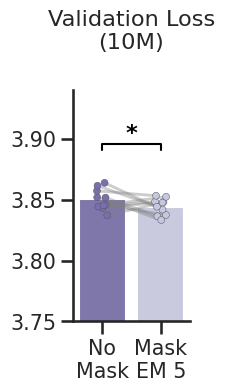

/tmp/ipykernel_476852/2698798670.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_data["condition"] = pd.Categorical(plot_data["condition"], categories=[no_mask_condition, condition_name], ordered=True)
/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col

Comparing Mask
EM 10 and No
Mask
{'mean                    ': -0.013513422012329145, '95%_CI around mean      ': (-0.017659356594086007, -0.00898563385009757), 'bootstrap-t-test p_value': 'p=0.0012'}
Old y, h 3.875 0.002
Y lim values (3.75, 3.94)
New y, h 3.8906 0.0056999999999999985


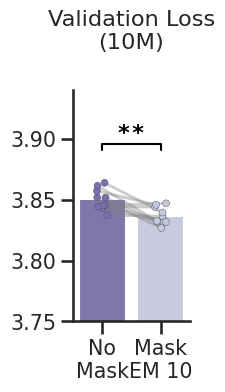

/tmp/ipykernel_476852/2698798670.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_data["condition"] = pd.Categorical(plot_data["condition"], categories=[no_mask_condition, condition_name], ordered=True)
/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col

Comparing Mask
No EM and No
Mask
{'mean                    ': 0.007327985763549849, '95%_CI around mean      ': (0.004357456564903219, 0.01030530214309719), 'bootstrap-t-test p_value': 'p=0.0008'}
Old y, h 3.875 0.002
Y lim values (3.75, 3.94)
New y, h 3.8906 0.0056999999999999985


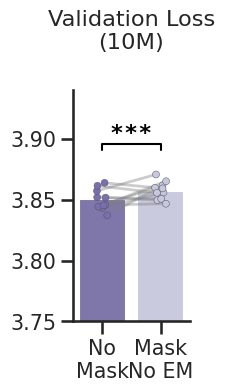

     pair_A       pair_B  mean                      \
0  No\nMask   Mask\nEM 5                 -0.005927   
1  No\nMask  Mask\nEM 10                 -0.013513   
2  No\nMask  Mask\nNo EM                  0.007328   

                          95%_CI around mean       bootstrap-t-test p_value  
0  (-0.008891927599906915, -0.0027906960248944047)                 p=0.0138  
1    (-0.017659356594086007, -0.00898563385009757)                 p=0.0012  
2      (0.004357456564903219, 0.01030530214309719)                 p=0.0008  


In [271]:
condition_triplet_map = {"nomask_EM01": "No\nMask", 
                         "ee002_EM01": "Mask\nNo EM", 
                         "ee002_EM05": "Mask\nEM 5", 
                         "ee002_EM10": "Mask\nEM 10"}

with sns.axes_style("ticks"), sns.plotting_context("talk", font_scale=.9):
    stats_test = []
    plot_data_r = seed_df.merge(loss_data, on="run_id", how="left")[["seed", "condition", "val_loss"]]
    plot_data_r = plot_data_r[plot_data_r["condition"].isin(["nomask_EM01", "ee002_EM01", "ee002_EM05", "ee002_EM10"])]
    plot_data_r["condition"] = pd.Categorical(plot_data_r["condition"], categories=["nomask_EM01", "ee002_EM01", "ee002_EM05", "ee002_EM10"], ordered=True)
    plot_data_r["condition"] = plot_data_r["condition"].map(condition_triplet_map)
    plot_data_r["condition"] = plot_data_r["condition"].astype(str)
    #plot_data_r.remove_categories(condition_triplet_map.values())
    #print(plot_data_r)
    #print(plot_data_r["condition"].unique())
    no_mask_condition = "No\nMask"
    
    for condition_name in plot_data_r["condition"].unique():
        #print("H1", condition)
        if condition_name != no_mask_condition:
            fig, ax = plt.subplots(1, 1, figsize=(1.5, 3))
            #plt.figure(figsize=(1.5, 3))
            plot_data = plot_data_r[plot_data_r["condition"].isin([no_mask_condition, condition_name])]
            #plot_data = plot_data.reset_index(drop=True)
            plot_data["condition"] = pd.Categorical(plot_data["condition"], categories=[no_mask_condition, condition_name], ordered=True)
            # print(plot_data)
            # print(plot_data.columns)
            # print(plot_data["condition"].unique())
            # #print(plot_data["condition"].cat.categories)
            sns.barplot(data=plot_data[["condition", "val_loss"]], x="condition", y="val_loss", hue="condition",  ax=ax,
                        errorbar=None, palette="Purples_r")
            
            sns.stripplot(data=plot_data[["condition", "val_loss"]], x="condition", y="val_loss", ax=ax, linewidth=0.35, palette="Purples_r", hue="condition")
            
            connect_dots(ax)

            #ax.axhline(y=plot_data[plot_data["condition"] == "No Mask"]["val_loss"].mean(), linestyle='--', color='red')

            #ax.set_ylabel("Validation Loss")
            ax.set_ylabel("")
            ax.set_ylim(3.78, 3.94)
            ax.set_xlabel("")
            ax.set_yticks(ax.get_yticks()[ax.get_yticks() <= 3.9])

            ax.set_title("Validation Loss\n(10M)", pad=30)

            # # Perform pairwise comparisons with "No Mask"
            res = annotate_given_colid(ax, plot_data["condition"].cat.categories.get_loc(condition_name), plot_data["condition"].cat.categories.get_loc(no_mask_condition), plot_data, 3.875, 0.002, "val_loss", h_factor=0.74) (do you have vector format?) - In Canva

# * Figure 4 from thesis (Effect of masking on performance for cross entropy loss)
# * Figure 5 from thesis (
            save_matplot_fig(fig, f"NoMask_vs_{save_cond_name}_val_loss.png", dpi=1000, folders_path="figure_5_sep")
            save_matplot_fig(fig, f"NoMask_vs_{save_cond_name}_val_loss.pdf", dpi=3000, folders_path="figure_5_sep")

    print(pd.DataFrame(stats_test))
    #save_matplot_fig(fig, "pairwise_comp_val_loss_withstats_v2_mq", dpi=1000)
    #save_matplot_fig(fig, "pairwise_comp_val_loss_withstats_v2_hq.pdf", dpi=3000)
    #save_matplot_fig(fig, "Fig2_val_loss_strong_mask_EM.pdf", dpi=3000)


/tmp/ipykernel_476852/1629932896.py:314: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby('seed').apply(lambda x: x[x['condition']==list(conditional_map.values())[1]]["score"].values[0] - x[x['condition']==list(conditional_map.values())[0]]["score"].values[0])
/tmp/ipykernel_476852/1629932896.py:314: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_t

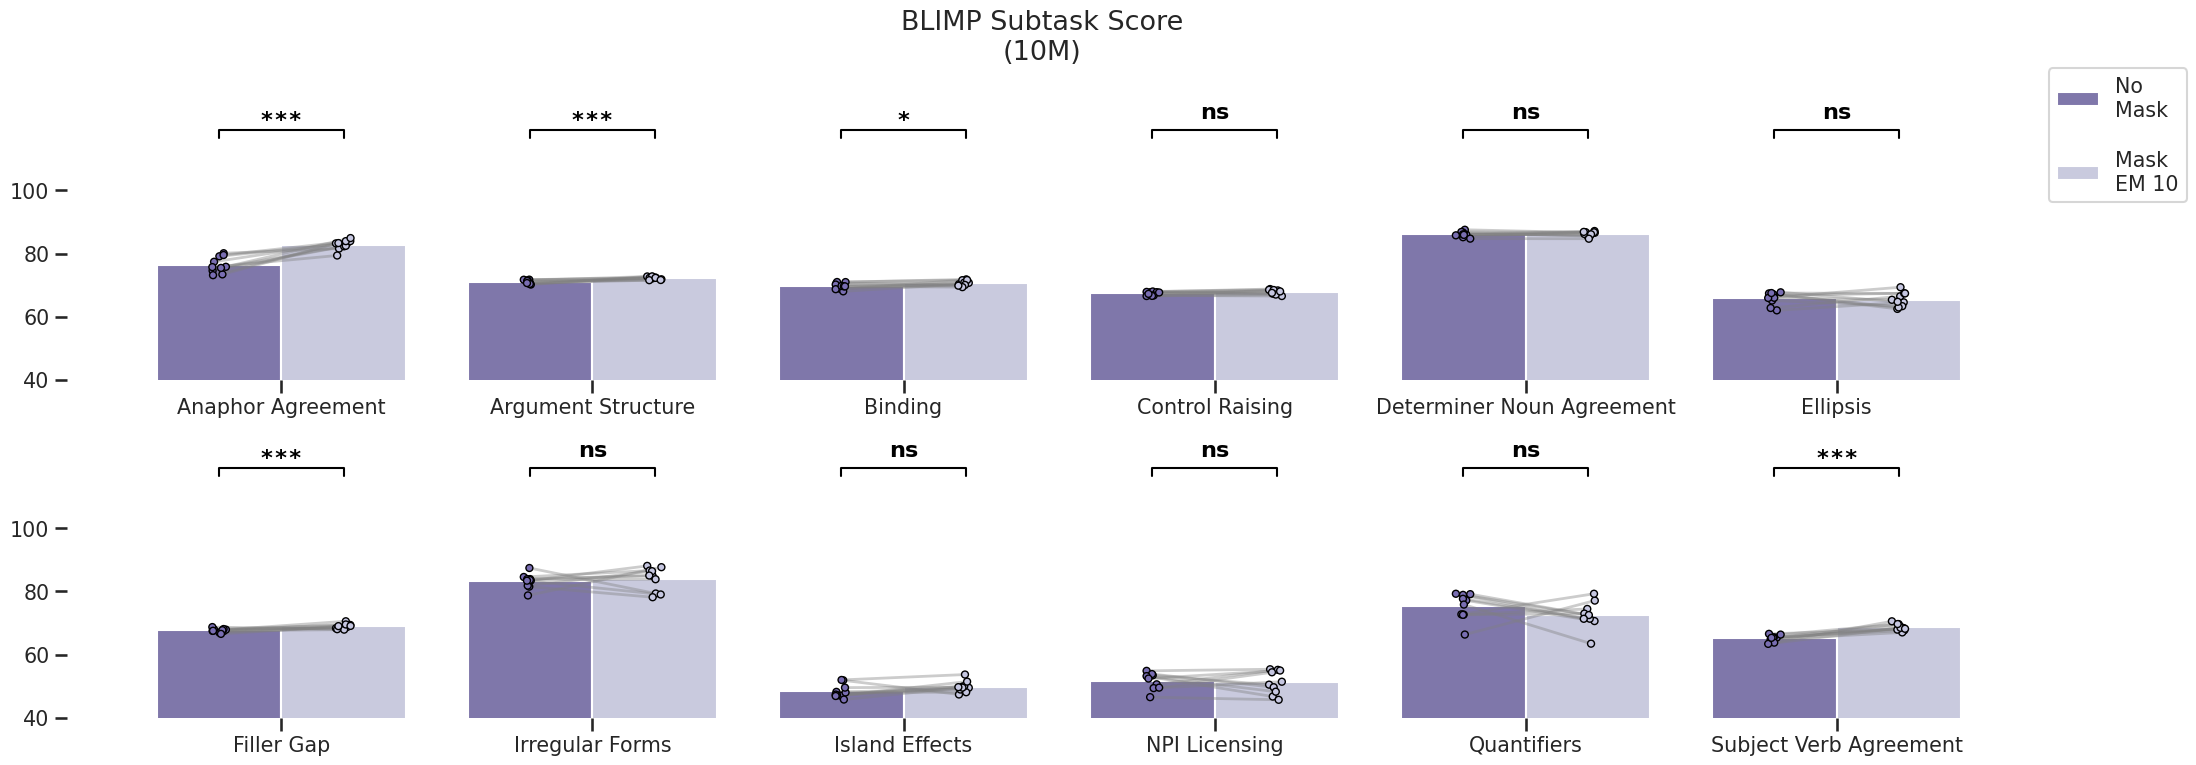

In [273]:

#Group by condition and get average of all BLIMP_avg and sort by that value
seed_df_blimp_indv = seed_df.merge(blimp_data, on="run_id", how="left")

#For this condition pair, plot all BLIMP tasks
#conditional_map = {"nomask_EM01": "No Mask", "ee002_EM10": "Exponential Mask\nEM10"}
#rcParams.update(params_two_col)
with sns.axes_style("ticks"), sns.plotting_context("talk", font_scale=.9):
    fig, ax = plt.subplots(2, 1)
    fig.set_size_inches(21, 7)
    fig.tight_layout()
    blimp_subtask_stats_test = []
    for row, axs in enumerate(ax):
        #Split blimp categories into 2 rows of subplots
        if row == 0:
            data_columns = [i[0] for i in blimp_categories[:6]] + ["condition", "seed"]
        else:
            data_columns = [i[0] for i in blimp_categories[6:12]] + ["condition", "seed"]

        ax = axs
        plot_data = seed_df_blimp_indv[data_columns][seed_df["condition"].isin(["nomask_EM01", "ee002_EM10"])]
        plot_data["condition"] = pd.Categorical(plot_data["condition"], categories=["nomask_EM01", "ee002_EM10"], ordered=True)
        plot_data["condition"] = plot_data["condition"].map(condition_triplet_map)
        
        #Pivot blimp_categories into rows 
        plot_data = pd.melt(plot_data, id_vars=["condition", "seed"], value_vars=[k for k in data_columns[:-2]                                                                                ]).rename(columns={"variable": "blimp_task", "value": "score"})
        
        sns.barplot(data=plot_data, x="blimp_task", y="score" , hue="condition",
                    dodge=True, ax=ax, errorbar=None, palette="Purples_r")
        
        #Add value labels to each bar slighly above the bar
        
        # for p in ax.patches:
        #     ax.annotate(format(p.get_height(), '.2f'), (p.get_x() + p.get_width() / 2., p.get_height()+3.5),
        #                 ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points')
        
        sns.stripplot(data=plot_data, x="blimp_task", y="score", hue="condition", dodge=True, jitter=0.05, ax=ax, alpha=1, edgecolor='black', linewidth=1, palette="Purples_r")
        connect_dots_ib(ax)
        
        #set title for each subplot but remove \n from mapping
        #ax.xaxis.set_tick_params(rotation=45)
        ax.set_ylim(40, 125)

        ax.set_yticks(ax.get_yticks()[ax.get_yticks() <= 100])
        
        #Remove legend for each subplot
        ax.get_legend().remove()
        ax.set_xlabel("")
        ax.set_ylabel("")
        for k in range(6):
            res = annotate_given_colid_ib(ax, k, plot_data, 101, 2, {x: condition_triplet_map[x] for x in ["nomask_EM01", "ee002_EM10"]})
            blimp_subtask_stats_test.append({**{"blimp_task": blimp_name_map[data_columns[k]],
                                                "pair_A":"nomask_EM01", "pair_B":"ee002_EM10"} , **res})
            
        
        #print(ax.get_xticklabels())
        ax.set_xticklabels([blimp_name_map[i.get_text()] for i in ax.get_xticklabels()])
        sns.despine(bottom=True, left=True)
    handles, labels = ax.get_legend_handles_labels()
    #Legend position is set to top right and overlapping with the plot
    fig.legend(handles[:2], labels[:2], loc='right', bbox_to_anchor=(1.05, 0.92), labelspacing=1.5)
    #fig.supylabel("BLIMP Score")
    #print(pd.DataFrame(blimp_subtask_stats_test))


    fig.suptitle("BLIMP Subtask Score\n(10M)", y = 1.1)

    save_matplot_fig(fig, "Fig9_blimp_subtask_10M.png", dpi=1000)
    save_matplot_fig(fig, "Fig9_blimp_subtask_10M.pdf", dpi=3000)


Comparing No
Mask and Mask
EM 10
{'mean                    ': -6.405930470347651, '95%_CI around mean      ': (-8.006134969325142, -4.897622699386511), 'bootstrap-t-test p_value': 'p < 0.0001'}
Old y, h 103 2
Y lim values (40.0, 125.0)
New y, h 116.5 2.55


/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])


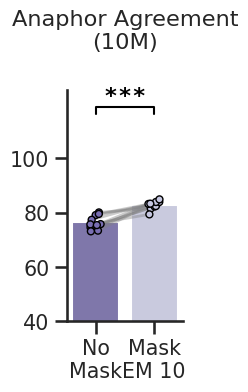

Comparing No
Mask and Mask
EM 10
{'mean                    ': -1.2706110572259874, '95%_CI around mean      ': (-1.6306983511154285, -0.9080989330746688), 'bootstrap-t-test p_value': 'p=0.0006'}
Old y, h 103 2
Y lim values (40.0, 125.0)
New y, h 116.5 2.55


/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])


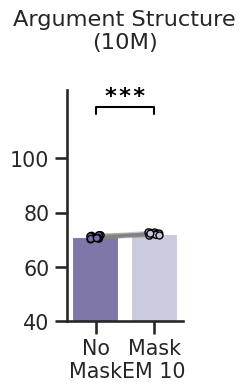

Comparing No
Mask and Mask
EM 10
{'mean                    ': -0.8919560700504491, '95%_CI around mean      ': (-1.3579697239536812, -0.408095874146614), 'bootstrap-t-test p_value': 'p=0.0258'}
Old y, h 103 2
Y lim values (40.0, 125.0)
New y, h 116.5 2.55


/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])


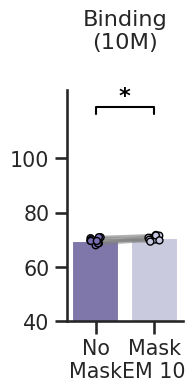

Comparing No
Mask and Mask
EM 10
{'mean                    ': -0.417587273530728, '95%_CI around mean      ': (-0.8638974812196353, 0.07070260715862141), 'bootstrap-t-test p_value': 'p=0.1816'}
Old y, h 103 2
Y lim values (40.0, 125.0)
New y, h 116.5 2.55


/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])


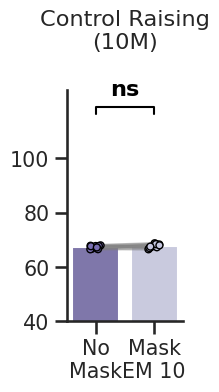

Comparing No
Mask and Mask
EM 10
{'mean                    ': -0.12330946698486969, '95%_CI around mean      ': (-0.7664081145584656, 0.4601233094670205), 'bootstrap-t-test p_value': 'p=0.6818'}
Old y, h 103 2
Y lim values (40.0, 125.0)
New y, h 116.5 2.55


/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])


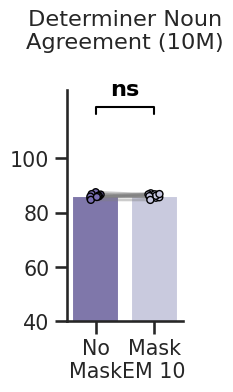

Comparing No
Mask and Mask
EM 10
{'mean                    ': 0.42725173210161244, '95%_CI around mean      ': (-1.726327944572749, 2.4193129330254073), 'bootstrap-t-test p_value': 'p=0.7118'}
Old y, h 103 2
Y lim values (40.0, 125.0)
New y, h 116.5 2.55


/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])


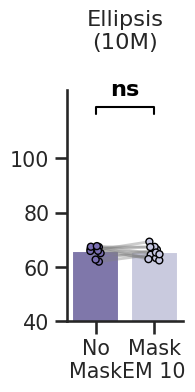

Comparing No
Mask and Mask
EM 10
{'mean                    ': -1.283846872082158, '95%_CI around mean      ': (-1.8362900715841792, -0.7749766573295972), 'bootstrap-t-test p_value': 'p=0.0004'}
Old y, h 103 2
Y lim values (40.0, 125.0)
New y, h 116.5 2.55


/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])


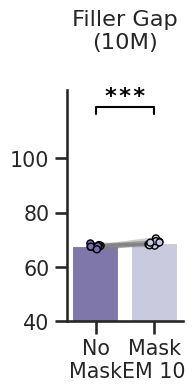

Comparing No
Mask and Mask
EM 10
{'mean                    ': -0.6768447837150078, '95%_CI around mean      ': (-3.2113231552163013, 1.9287531806616016), 'bootstrap-t-test p_value': 'p=0.625'}
Old y, h 103 2
Y lim values (40.0, 125.0)
New y, h 116.5 2.55


/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])


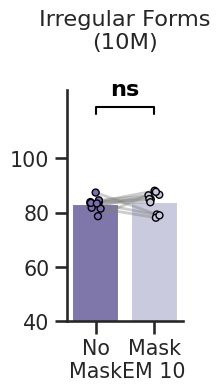

Comparing No
Mask and Mask
EM 10
{'mean                    ': -1.4387144992526024, '95%_CI around mean      ': (-3.2100149476830824, 0.310257847533659), 'bootstrap-t-test p_value': 'p=0.1534'}
Old y, h 103 2
Y lim values (40.0, 125.0)
New y, h 116.5 2.55


/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])


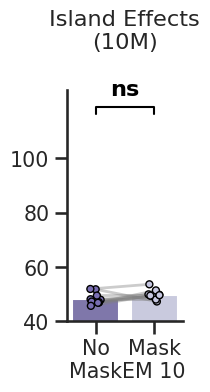

Comparing No
Mask and Mask
EM 10
{'mean                    ': 0.4752505314303086, '95%_CI around mean      ': (-2.6193440631642946, 3.4315593683571146), 'bootstrap-t-test p_value': 'p=0.7812'}
Old y, h 103 2
Y lim values (40.0, 125.0)
New y, h 116.5 2.55


/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])


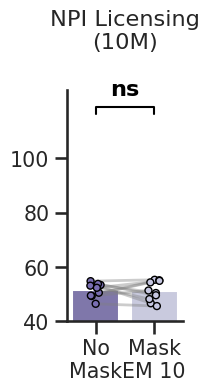

Comparing No
Mask and Mask
EM 10
{'mean                    ': 2.660999484801642, '95%_CI around mean      ': (-0.9119010819165674, 5.942812982998472), 'bootstrap-t-test p_value': 'p=0.2148'}
Old y, h 103 2
Y lim values (40.0, 125.0)
New y, h 116.5 2.55


/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])


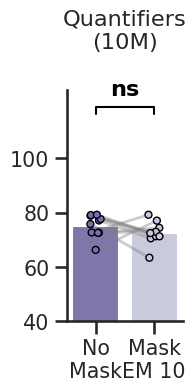

Comparing No
Mask and Mask
EM 10
{'mean                    ': -3.53206865401989, '95%_CI around mean      ': (-4.242140921409223, -2.784101174345102), 'bootstrap-t-test p_value': 'p=0.0004'}
Old y, h 103 2
Y lim values (40.0, 125.0)
New y, h 116.5 2.55


/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])


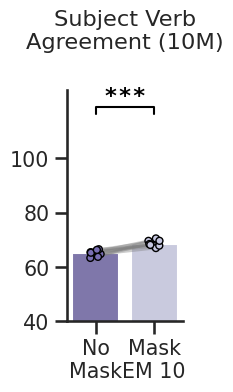

                   blimp_task       pair_A      pair_B  \
0           Anaphor Agreement  nomask_EM01  ee002_EM10   
1          Argument Structure  nomask_EM01  ee002_EM10   
2                     Binding  nomask_EM01  ee002_EM10   
3             Control Raising  nomask_EM01  ee002_EM10   
4   Determiner Noun Agreement  nomask_EM01  ee002_EM10   
5                    Ellipsis  nomask_EM01  ee002_EM10   
6                  Filler Gap  nomask_EM01  ee002_EM10   
7             Irregular Forms  nomask_EM01  ee002_EM10   
8              Island Effects  nomask_EM01  ee002_EM10   
9               NPI Licensing  nomask_EM01  ee002_EM10   
10                Quantifiers  nomask_EM01  ee002_EM10   
11     Subject Verb Agreement  nomask_EM01  ee002_EM10   

    mean                                        95%_CI around mean        \
0                  -6.405930    (-8.006134969325142, -4.897622699386511)   
1                  -1.270611  (-1.6306983511154285, -0.9080989330746688)   
2                

In [278]:
# Group by condition and get average of all BLIMP_avg and sort by that value
# seed_df_100M_blimp_indv = seed_df_100M.merge(blimp_data, on="run_id", how="left")
seed_df_blimp_indv = seed_df.merge(blimp_data, on="run_id", how="left")

# For this condition pair, plot all BLIMP tasks
with sns.axes_style("ticks"), sns.plotting_context("talk", font_scale=.9):
    blimp_subtask_stats_test = []
    for i, (blimp_task, blimp_div) in enumerate(blimp_categories):
        if blimp_div == "supplement":
            continue
        fig, ax = plt.subplots(1, 1, figsize=(1.5, 3))
        #fig.set_size_inches(10, 5)
    
        
        data_columns = [blimp_task, "condition", "seed"]
        plot_data = seed_df_blimp_indv[data_columns][seed_df["condition"].isin(["nomask_EM01", "ee002_EM10"])]
        
        plot_data = pd.melt(plot_data, id_vars=["condition", "seed"], value_vars=[blimp_task]).rename(columns={"variable": "blimp_task", "value": "score"})
        plot_data["condition"] = plot_data["condition"].map({x: condition_triplet_map[x] for x in ["nomask_EM01", "ee002_EM10"]})

        plot_data["condition"] = pd.Categorical(plot_data["condition"], categories=["No\nMask", "Mask\nEM 10"], ordered=True)

        #print(plot_data)
        sns.barplot(data=plot_data, x="condition", y="score", ax=ax, errorbar=None, palette="Purples_r", hue="condition")
        
        # for p in ax.patches:
        #     ax.annotate(format(p.get_height(), '.2f'), (p.get_x() + p.get_width() / 2., p.get_height() + 5.5),
        #                 ha='center', va='center', xytext=(0, 10), textcoords='offset points')
        
        sns.stripplot(data=plot_data, x="condition", y="score", ax=ax, alpha=1, edgecolor='black', linewidth=1, palette="Purples_r", hue="condition")

        connect_dots(ax)
        
        ax.set_ylim(40, 125)
        #ax.get_legend().remove()
        #ax.set_xlabel(blimp_name_map[blimp_task].replace(" ", "\n"), labelpad=10)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_yticks(ax.get_yticks()[ax.get_yticks() <= 100])
        
        res = annotate_given_colid(ax, 0, 1, plot_data, 103, 2, "score")
        blimp_subtask_stats_test.append({**{"blimp_task": blimp_name_map[blimp_task], "pair_A": "nomask_EM01", "pair_B": "ee002_EM10"}, **res})
        
        #ax.set_xticklabels([blimp_name_map[i.get_text()] for i in ax.get_xticklabels()])
        sns.despine()
        
        title_str = blimp_name_map[blimp_task]
        
        #Break and join the title string into 2 lines
        if len(title_str.split()) > 2:
            title_str = " ".join(title_str.split()[:2]) + "\n" + " ".join(title_str.split()[2:]) + " (10M)"
        else:
            title_str = title_str + "\n(10M)"

        plt.title(title_str, pad=30)
        plt.show()
        save_name = blimp_name_map[blimp_task].replace("\n", " ")
        save_matplot_fig(fig, f"Fig9_blimp_subtask_{blimp_task}_10M.png", dpi=1000, folders_path="figure_9_10M_sep")
        save_matplot_fig(fig, f"Fig9_blimp_subtask_{blimp_task}_10M.pdf", dpi=3000, folders_path="figure_9_10M_sep")

    print(pd.DataFrame(blimp_subtask_stats_test))
    # save_matplot_fig(fig, "Fig6_blimp_subtasks.pdf", dpi=3000)


In [8]:
#Since only 5 seed values are there for all different settings - 42, 466, 616, 1337, 2347


seed_df_masks_10M = run_data_unfiltered[
    (run_data_unfiltered["curriculum_learning"] == False) & (run_data_unfiltered["dataset"] == "babylm_full_bpe_8k") & 
    (run_data_unfiltered["n_layer"] == 6) & (run_data_unfiltered["batch_size"] == 32) & (run_data_unfiltered["num_iterations"] == 44000) & (run_data_unfiltered["seed"].isin([42, 466, 616, 1337, 2347]))
    & (((run_data_unfiltered["mask_type"].isin(["Non"]))  & (run_data_unfiltered["run_id"] != 5496427)) 
        | ((run_data_unfiltered["mask_type"].isin(["exponential_new"])) & (run_data_unfiltered["mask_decay_rate"].isin([0.5,1,2,3,4])) & (run_data_unfiltered["echoic_memory"].isin([1,5,10]))))
][["run_id", "output_folder_name", "n_layer", "n_head", "block_size", "n_embd", "batch_size", "learning_rate", "mask_type", "mask_decay_rate", "echoic_memory", "dataset", "seed"]].reset_index(drop=True)


seed_df_masks_10M = seed_df_masks_10M.sort_values(by=["mask_type", "mask_decay_rate", "echoic_memory", "seed"]).reset_index(drop=True)

seed_df_masks_10M["condition"] = seed_df_masks_10M["mask_type"].apply(lambda x: "Mask" if x != "Non" else "No\nMask")
seed_df_masks_10M["x_condition"] = seed_df_masks_10M["condition"] + " " + seed_df_masks_10M["mask_decay_rate"].astype(str).apply(lambda x: "" if x == "0.0" else x) 
seed_df_masks_10M["x_condition"] = seed_df_masks_10M["x_condition"].apply(lambda x: x.strip())

seed_df_masks_10M["condition"] = seed_df_masks_10M["condition"] + "\nEM" + seed_df_masks_10M["echoic_memory"].astype(str).str.zfill(2)
seed_df_masks_10M = seed_df_masks_10M.sort_values(by=["seed", "condition"]).reset_index(drop=True)

seed_df_masks_10M = seed_df_masks_10M.merge(loss_data[['run_id', 'val_loss', 'train_loss']], on="run_id", how="left")


seed_df_masks_10M["echoic_memory_flag"] = seed_df_masks_10M["echoic_memory"].apply(lambda x: False if x == 1 else True)

seed_df_masks_10M.sort_values(by=['x_condition', 'echoic_memory', 'seed'], inplace=True)

seed_df_masks_10M

,run_id,output_folder_name,n_layer,n_head,block_size,n_embd,batch_size,learning_rate,mask_type,mask_decay_rate,echoic_memory,dataset,seed,condition,x_condition,val_loss,train_loss,echoic_memory_flag
0,7678419,out-babylm_full_bpe_8k-6x6-mask_ee0p5_em01-767...,6,6,256,384,32.0,0.0005,exponential_new,0.5,1,babylm_full_bpe_8k,42,Mask\nEM01,Mask 0.5,3.849141,2.902341,False
16,7678422,out-babylm_full_bpe_8k-6x6-mask_ee0p5_em01-767...,6,6,256,384,32.0,0.0005,exponential_new,0.5,1,babylm_full_bpe_8k,466,Mask\nEM01,Mask 0.5,3.852789,2.902600,False
32,7678421,out-babylm_full_bpe_8k-6x6-mask_ee0p5_em01-767...,6,6,256,384,32.0,0.0005,exponential_new,0.5,1,babylm_full_bpe_8k,616,Mask\nEM01,Mask 0.5,3.844611,2.897148,False
48,6810321,out-babylm_full_bpe_8k-6x6-mask_ee0p5_em01-681...,6,6,256,384,32.0,0.0005,exponential_new,0.5,1,babylm_full_bpe_8k,1337,Mask\nEM01,Mask 0.5,3.851278,2.890961,False
64,7678420,out-babylm_full_bpe_8k-6x6-mask_ee0p5_em01-767...,6,6,256,384,32.0,0.0005,exponential_new,0.5,1,babylm_full_bpe_8k,2347,Mask\nEM01,Mask 0.5,3.842221,2.896809,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15,6892212,out-babylm_full_bpe_8k-6x6-nomask-6892212_s42,6,6,256,384,32.0,0.0005,Non,0.0,1,babylm_full_bpe_8k,42,No\nMask\nEM01,No\nMask,3.851849,2.912897,False
31,6892220,out-babylm_full_bpe_8k-6x6-nomask-6892220_s466,6,6,256,384,32.0,0.0005,Non,0.0,1,babylm_full_bpe_8k,466,No\nMask\nEM01,No\nMask,3.857377,2.915270,False
47,6892216,out-babylm_full_bpe_8k-6x6-nomask-6892216_s616,6,6,256,384,32.0,0.0005,Non,0.0,1,babylm_full_bpe_8k,616,No\nMask\nEM01,No\nMask,3.837300,2.907289,False
63,6892222,out-babylm_full_bpe_8k-6x6-nomask-6892222_s1337,6,6,256,384,32.0,0.0005,Non,0.0,1,babylm_full_bpe_8k,1337,No\nMask\nEM01,No\nMask,3.845519,2.897251,False


/tmp/ipykernel_12206/1225758861.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=stripplot_data, x='x_condition', y='val_loss', ax=axs[i, j], alpha=0.5, palette="Purples_r", edgecolor='black', linewidth=1, color='black')
/tmp/ipykernel_12206/1225758861.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=stripplot_data, x='x_condition', y='val_loss', ax=axs[i, j], alpha=0.5, palette="Purples_r", edgecolor='black', linewidth=1, color='black')
/tmp/ipykernel_12206/1225758861.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripp

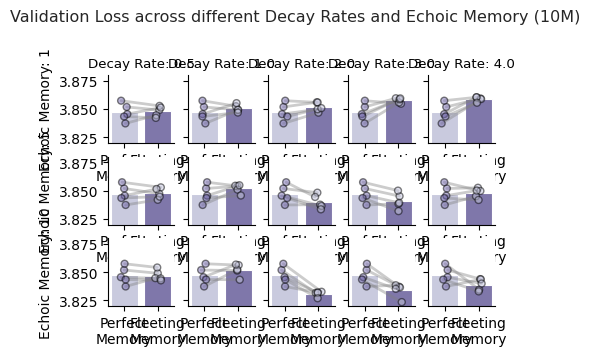

In [16]:
fig, axs = plt.subplots(3, 5, figsize=(5, 3))
# fig.tight_layout()
# print(len(seed_df_masks_10M['echoic_memory'].unique()))
# print(len(seed_df_masks_10M[seed_df_masks_10M['x_condition'] != 'No\nMask']['x_condition'].unique()))
# print(seed_df_masks_10M['echoic_memory'].unique())
# print(seed_df_masks_10M[seed_df_masks_10M['x_condition'] != 'No\nMask']['x_condition'].unique())
with sns.axes_style("ticks"), sns.plotting_context("paper"):
    for i, em in enumerate(seed_df_masks_10M['echoic_memory'].unique()):
        for j, x_cond in enumerate(seed_df_masks_10M[seed_df_masks_10M['x_condition'] != 'No\nMask']['x_condition'].unique()):
            
            barplot_data = seed_df_masks_10M[(seed_df_masks_10M['echoic_memory'] == em) & (seed_df_masks_10M['x_condition'] == x_cond) | (seed_df_masks_10M['echoic_memory'] == 1) & (seed_df_masks_10M['x_condition'] == 'No\nMask')]
            barplot_data = barplot_data.sort_values(by='seed')
            barplot_data["x_condition"] = pd.Categorical(barplot_data["x_condition"], categories=["No\nMask", x_cond], ordered=True)

            stripplot_data = seed_df_masks_10M[(seed_df_masks_10M['echoic_memory'] == em) & (seed_df_masks_10M['x_condition'] == x_cond) | (seed_df_masks_10M['echoic_memory'] == 1) & (seed_df_masks_10M['x_condition'] == 'No\nMask')]
            stripplot_data = stripplot_data.sort_values(by='seed')
            stripplot_data["x_condition"] = pd.Categorical(stripplot_data["x_condition"], categories=["No\nMask", x_cond], ordered=True)

            barplot_data["x_condition"] = barplot_data["x_condition"].apply(lambda x: {x_cond: "Fleeting\nMemory"}[x] if x != "No\nMask" else "Perfect\nMemory")
            stripplot_data["x_condition"] = stripplot_data["x_condition"].apply(lambda x: {x_cond: "Fleeting\nMemory"}[x] if x != "No\nMask" else "Perfect\nMemory")

            sns.barplot(data=barplot_data, x='x_condition', y='val_loss', ax=axs[i, j], errorbar=None, palette="Purples_r", hue='condition')
            sns.stripplot(data=stripplot_data, x='x_condition', y='val_loss', ax=axs[i, j], alpha=0.5, palette="Purples_r", edgecolor='black', linewidth=1, color='black')

            
            if i == 0:
                axs[i, j].set_title(f"Decay Rate: {x_cond.split(' ')[1]}")

            axs[i, j].set_ylim(3.82, 3.88)
            axs[i,j].set_xlabel('')
            axs[i,j].set_ylabel('')
            connect_dots(axs[i, j])
            
            if j != 0:
                axs[i, j].set_yticklabels([])
            else:
                axs[i, j].set_ylabel(f"Echoic Memory: {em}")
            
            axs[i, j].legend().remove()
            sns.despine(ax=axs[i, j])
            # for p in axs[i, j].patches:
            #     axs[i, j].annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()+0.025), ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=8)
    fig.suptitle("Validation Loss across different Decay Rates and Echoic Memory (10M)", y=1.1)

    # save_matplot_fig(fig, "many_masking_val_loss_10M.png", dpi=1000)
    # save_matplot_fig(fig, "many_masking_val_loss_10M.pdf", dpi=3000)

/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])


Comparing Mask and No
Mask
{'mean                    ': -0.02235786914825453, '95%_CI around mean      ': (-0.024119974970817873, -0.02058522284030914), 'bootstrap-t-test p_value': 'p < 0.0001'}
Old y, h 3.475 0.003
Y lim values (3.3, 3.5)
New y, h 3.48 0.006000000000000005
[1.5 3. ]


/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])


Comparing Mask and No
Mask
{'mean                    ': 2.382027045560527, '95%_CI around mean      ': (1.391799382715059, 3.286535514823016), 'bootstrap-t-test p_value': 'p=0.0102'}
Old y, h 76.5 0.125
Y lim values (68.0, 78.0)
New y, h 77.0 0.3
[1.5 3. ]


/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])


Comparing Mask and No
Mask
{'mean                    ': -49.56005969300459, '95%_CI around mean      ': (-83.95175736644029, -14.956032638443304), 'bootstrap-t-test p_value': 'p=0.033'}
Old y, h 1850 12.5
Y lim values (1000.0, 2000.0)
New y, h 1900.0 30.0
mask_type
exponential_new    10
Non                10
Name: count, dtype: int64


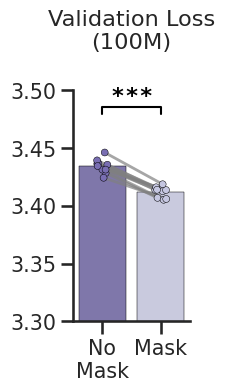

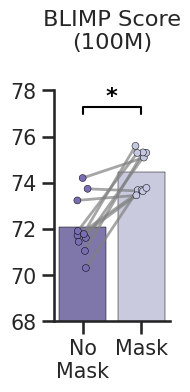

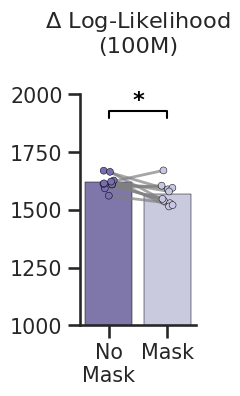

In [288]:

seed_df_100M = run_data_unfiltered[
    (run_data_unfiltered["curriculum_learning"] == False) & (run_data_unfiltered["dataset"] == "babylm_full_bpe_100M_8k") & 
    (run_data_unfiltered["n_layer"] == 6) & (run_data_unfiltered["batch_size"] == 32) & (run_data_unfiltered["num_iterations"] == 44000)
    & (((run_data_unfiltered["mask_type"].isin(["Non"]))  & (run_data_unfiltered["run_id"] != 5496427))
        | ((run_data_unfiltered["mask_type"].isin(["exponential_new"])) & (run_data_unfiltered["mask_decay_rate"] == 2) & (run_data_unfiltered["echoic_memory"] == 10) & (run_data_unfiltered["run_id"] != 8456913)))
][["run_id", "output_folder_name", "n_layer", "n_head", "block_size", "n_embd", "batch_size", "learning_rate", "mask_type", "mask_decay_rate", "echoic_memory", "dataset", "seed"]].reset_index(drop=True)

seed_df_100M["condition"] = seed_df_100M["mask_type"].apply(lambda x: "Mask" if x != "Non" else "No\nMask")
seed_df_100M = seed_df_100M.sort_values(by=["seed", "condition"]).reset_index(drop=True)

seed_df_100M["condition"] = pd.Categorical(seed_df_100M["condition"], categories=["No\nMask", "Mask"], ordered=True)

seed_df_100M = seed_df_100M.merge(loss_data[['run_id', 'val_loss', 'train_loss']], on="run_id", how="left")
seed_df_100M = seed_df_100M.merge(blimp_data[["run_id", "blimp_avg"]], on="run_id", how="left")
seed_df_100M = seed_df_100M.merge(reading_time_fit_df_osh[["ModelID", "Delta Log-Likelihood", "Data Size"]].add_suffix("_osh"), how="left", left_on="run_id", right_on="ModelID_osh",).drop(columns=["ModelID_osh"])
seed_df_100M["delta_log_likelihood_avg_osh"] = seed_df_100M["Delta Log-Likelihood_osh"] / seed_df_100M["Data Size_osh"]
seed_df_100M = seed_df_100M.merge(reading_time_fit_df_wil[["ModelID", "Delta Log-Likelihood", "Data Size"]].add_suffix("_wil"), how="left", left_on="run_id", right_on="ModelID_wil",).drop(columns=["ModelID_wil"])
seed_df_100M["delta_log_likelihood_avg_wil"] = seed_df_100M["Delta Log-Likelihood_wil"] / seed_df_100M["Data Size_wil"]
seed_df_100M = seed_df_100M.merge(reading_time_fit_df_wil2[["ModelID", "Delta Log-Likelihood", "Data Size"]].add_suffix("_wil2"), how="left", left_on="run_id", right_on="ModelID_wil2",).drop(columns=["ModelID_wil2"])
seed_df_100M["delta_log_likelihood_avg_wil2"] = seed_df_100M["Delta Log-Likelihood_wil2"] / seed_df_100M["Data Size_wil2"]


#Plot validation loss, BLIMP scores and reading time fit for 100M dataset

with sns.axes_style("ticks"), sns.plotting_context("talk", font_scale=.9):
    fig, ax = plt.subplots(1, 1, figsize=(1.5, 3))
    sns.stripplot(data=seed_df_100M, x="condition", y="val_loss", hue = "condition", palette="Purples_r", edgecolor='k', linewidth=0.35, ax=ax)
    connect_dots(ax, alpha=0.7)
    sns.barplot(data=seed_df_100M, x="condition", y="val_loss", hue="condition", palette="Purples_r", ax=ax, edgecolor='k', linewidth=0.35, errorbar=None, alpha=1)
    
    ax.set_ylim(3.3,3.5)
    #ax.set_ylabel("Validation Loss (100M)")
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_title("Validation Loss\n(100M)", pad=30)
    
    annotate_given_colid(ax, 1, 0, seed_df_100M, 3.475, 0.003, "val_loss")
    sns.despine()
    print(fig.get_size_inches())
    save_matplot_fig(fig, "100M_pairwise_val_loss.png", dpi=1000, folders_path = "100M_pairwise_sep")
    save_matplot_fig(fig, "100M_pairwise_val_loss.pdf", dpi=3000, folders_path = "100M_pairwise_sep")

with sns.axes_style("ticks"), sns.plotting_context("talk", font_scale=.9):

    #plt.figure(figsize=(1.5,3))
    fig, ax = plt.subplots(1, 1, figsize=(1.5, 3))
    sns.stripplot(data=seed_df_100M, x="condition", y="blimp_avg", hue = "condition", palette="Purples_r", edgecolor='k', linewidth=0.35, ax=ax)
    connect_dots(ax, alpha=0.7)
    sns.barplot(data=seed_df_100M, x="condition", y="blimp_avg", hue="condition", palette="Purples_r", ax=ax, edgecolor='k', linewidth=0.35, errorbar=None, alpha=1)
    
    ax.set_ylim(68, 78)
    #ax.set_ylabel("BLIMP Score")
    ax.set_ylabel("")
    ax.set_xlabel("")

    ax.set_title("BLIMP Score\n(100M)", pad=30)

    #Set number of y ticks as 5
    ax.yaxis.set_major_locator(plt.MaxNLocator(5))    
    annotate_given_colid(ax, 1, 0, seed_df_100M, 76.5, 0.125, "blimp_avg")
    sns.despine()
    print(fig.get_size_inches())
    save_matplot_fig(fig, "100M_pairwise_blimp_score.png", dpi=1000, folders_path = "100M_pairwise_sep")
    save_matplot_fig(fig, "100M_pairwise_blimp_score.pdf", dpi=3000, folders_path = "100M_pairwise_sep")

with sns.axes_style("ticks"), sns.plotting_context("talk", font_scale=.9):
    #plt.figure(figsize=(1.5,3))
    fig, ax = plt.subplots(1, 1, figsize=(1.5, 3))
    sns.stripplot(data=seed_df_100M, x="condition", y="Delta Log-Likelihood_osh", hue = "condition", palette="Purples_r", edgecolor='k', linewidth=0.35, ax=ax)
    connect_dots(ax, alpha=0.7)
    sns.barplot(data=seed_df_100M, x="condition", y="Delta Log-Likelihood_osh", hue="condition", palette="Purples_r", ax=ax, edgecolor='k', linewidth=0.35, errorbar=None, alpha=1)

    ax.set_ylim(1000,2000)
    ax.yaxis.set_major_locator(plt.MaxNLocator(4))
    #ax.set_ylabel("$\Delta$ Log-Likelihood")
    ax.set_ylabel("")
    ax.set_xlabel("")

    ax.set_title("$\Delta$ Log-Likelihood\n(100M)", pad=30)
    
    annotate_given_colid(ax, 1, 0, seed_df_100M, 1850, 12.5, "Delta Log-Likelihood_osh")
    sns.despine()
    save_matplot_fig(fig, "100M_pairwise_reading_time_fit.png", dpi=1000, folders_path = "100M_pairwise_sep")
    save_matplot_fig(fig, "100M_pairwise_reading_time_fit.pdf", dpi=3000, folders_path = "100M_pairwise_sep")


print(seed_df_100M["mask_type"].value_counts())
#seed_df_100M

/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Comparing Mask and No
Mask
{'mean                    ': -0.02235786914825453, '95%_CI around mean      ': (-0.024119974970817873, -0.02058522284030914), 'bootstrap-t-test p_value': 'p < 0.0001'}
Old y, h 3.475 0.003
Y lim values (3.3, 3.5)
New y, h 3.48 0.006000000000000005


/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Comparing Mask and No
Mask
{'mean                    ': 2.382027045560527, '95%_CI around mean      ': (1.391799382715059, 3.286535514823016), 'bootstrap-t-test p_value': 'p=0.0102'}
Old y, h 76.5 0.125
Y lim values (68.0, 78.0)
New y, h 77.0 0.3


/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Comparing Mask and No
Mask
{'mean                    ': -49.56005969300459, '95%_CI around mean      ': (-83.95175736644029, -14.956032638443304), 'bootstrap-t-test p_value': 'p=0.033'}
Old y, h 1850 12.5
Y lim values (1000.0, 2000.0)
New y, h 1900.0 30.0


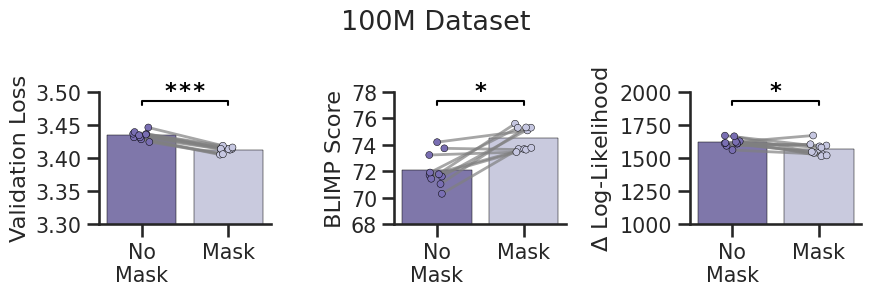

In [ ]:
seed_df_100M = run_data_unfiltered[
    (run_data_unfiltered["curriculum_learning"] == False) & (run_data_unfiltered["dataset"] == "babylm_full_bpe_100M_8k") & 
    (run_data_unfiltered["n_layer"] == 6) & (run_data_unfiltered["batch_size"] == 32) & (run_data_unfiltered["num_iterations"] == 44000)
    & (((run_data_unfiltered["mask_type"].isin(["Non"]))  & (run_data_unfiltered["run_id"] != 5496427))
        | ((run_data_unfiltered["mask_type"].isin(["exponential_new"])) & (run_data_unfiltered["mask_decay_rate"] == 2) & (run_data_unfiltered["echoic_memory"] == 10) & (run_data_unfiltered["run_id"] != 8456913)))
][["run_id", "output_folder_name", "n_layer", "n_head", "block_size", "n_embd", "batch_size", "learning_rate", "mask_type", "mask_decay_rate", "echoic_memory", "dataset", "seed"]].reset_index(drop=True)

seed_df_100M["condition"] = seed_df_100M["mask_type"].apply(lambda x: "Mask" if x != "Non" else "No\nMask")
seed_df_100M = seed_df_100M.sort_values(by=["seed", "condition"]).reset_index(drop=True)

seed_df_100M["condition"] = pd.Categorical(seed_df_100M["condition"], categories=["No\nMask", "Mask"], ordered=True)

seed_df_100M = seed_df_100M.merge(loss_data[['run_id', 'val_loss', 'train_loss']], on="run_id", how="left")
seed_df_100M = seed_df_100M.merge(blimp_data[["run_id", "blimp_avg"]], on="run_id", how="left")
seed_df_100M = seed_df_100M.merge(reading_time_fit_df_osh[["ModelID", "Delta Log-Likelihood", "Data Size"]].add_suffix("_osh"), how="left", left_on="run_id", right_on="ModelID_osh",).drop(columns=["ModelID_osh"])
seed_df_100M["delta_log_likelihood_avg_osh"] = seed_df_100M["Delta Log-Likelihood_osh"] / seed_df_100M["Data Size_osh"]
seed_df_100M = seed_df_100M.merge(reading_time_fit_df_wil[["ModelID", "Delta Log-Likelihood", "Data Size"]].add_suffix("_wil"), how="left", left_on="run_id", right_on="ModelID_wil",).drop(columns=["ModelID_wil"])
seed_df_100M["delta_log_likelihood_avg_wil"] = seed_df_100M["Delta Log-Likelihood_wil"] / seed_df_100M["Data Size_wil"]
seed_df_100M = seed_df_100M.merge(reading_time_fit_df_wil2[["ModelID", "Delta Log-Likelihood", "Data Size"]].add_suffix("_wil2"), how="left", left_on="run_id", right_on="ModelID_wil2",).drop(columns=["ModelID_wil2"])
seed_df_100M["delta_log_likelihood_avg_wil2"] = seed_df_100M["Delta Log-Likelihood_wil2"] / seed_df_100M["Data Size_wil2"]

# Plot validation loss, BLIMP scores and reading time fit for 100M dataset
with sns.axes_style("ticks"), sns.plotting_context("talk", font_scale=.9):
    fig, axs = plt.subplots(1, 3, figsize=(9, 3))

    # Validation Loss
    ax = sns.stripplot(data=seed_df_100M, x="condition", y="val_loss", hue="condition", palette="Purples_r", edgecolor='k', linewidth=0.35, ax=axs[0])
    connect_dots(ax, alpha=0.7)
    sns.barplot(data=seed_df_100M, x="condition", y="val_loss", hue="condition", palette="Purples_r", ax=axs[0], edgecolor='k', linewidth=0.35, errorbar=None, alpha=1)
    axs[0].set_ylim(3.3, 3.5)
    axs[0].set_ylabel("Validation Loss")
    axs[0].set_xlabel("")
    #axs[0].set_title("Validation Loss\n(100M)", pad=30)
    axs[0].yaxis.set_major_locator(plt.MaxNLocator(5))
    annotate_given_colid(axs[0], 1, 0, seed_df_100M, 3.475, 0.003, "val_loss")
    axs[0].legend().remove()
    sns.despine(ax=axs[0])

    # BLIMP Score
    ax = sns.stripplot(data=seed_df_100M, x="condition", y="blimp_avg", hue="condition", palette="Purples_r", edgecolor='k', linewidth=0.35, ax=axs[1])
    connect_dots(ax, alpha=0.7)
    sns.barplot(data=seed_df_100M, x="condition", y="blimp_avg", hue="condition", palette="Purples_r", ax=axs[1], edgecolor='k', linewidth=0.35, errorbar=None, alpha=1)
    axs[1].set_ylim(68, 78)
    axs[1].set_ylabel("BLIMP Score")
    axs[1].set_xlabel("")
    #axs[1].set_title("BLIMP Score\n(100M)", pad=30)
    axs[1].yaxis.set_major_locator(plt.MaxNLocator(5))
    annotate_given_colid(axs[1], 1, 0, seed_df_100M, 76.5, 0.125, "blimp_avg")
    axs[1].legend().remove()
    sns.despine(ax=axs[1])

    # Reading Time Fit
    ax = sns.stripplot(data=seed_df_100M, x="condition", y="Delta Log-Likelihood_osh", hue="condition", palette="Purples_r", 
                       edgecolor='k', linewidth=0.35, ax=axs[2])
    connect_dots(ax, alpha=0.7)
    sns.barplot(data=seed_df_100M, x="condition", y="Delta Log-Likelihood_osh", hue="condition", palette="Purples_r", ax=axs[2], edgecolor='k', linewidth=0.35, errorbar=None, alpha=1)
    axs[2].set_ylim(1000, 2000)
    axs[2].yaxis.set_major_locator(plt.MaxNLocator(4))
    axs[2].set_ylabel("$\Delta$ Log-Likelihood")
    axs[2].set_xlabel("")
    #axs[2].set_title("$\Delta$ Log-Likelihood\n(100M)", pad=30)
    annotate_given_colid(axs[2], 1, 0, seed_df_100M, 1850, 12.5, "Delta Log-Likelihood_osh")
    axs[2].legend().remove()
    sns.despine(ax=axs[2])

    
    fig.suptitle("100M Dataset", y = 1)
    plt.tight_layout()
    plt.show()

    save_matplot_fig(fig, "100M_pairwise_results_combined.png", dpi=1000)
    save_matplot_fig(fig, "100M_pairwise_results_combined.pdf", dpi=3000)

Lowest validation loss seed:  6747
Number of rows before filtering:  3280
Number of rows after filtering:  328
Comparing No
Curriculum and Curriculum
Log
Pacing


/tmp/ipykernel_1881641/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])
/tmp/ipykernel_1881641/3790235194.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(labels = ax[0].get_xticklabels())


{'mean                    ': -0.08043069839477543, '95%_CI around mean      ': (-0.0887544769048693, -0.07315832793712629), 'bootstrap-t-test p_value': 'p < 0.0001'}
Old y, h 3.965 0.005
Y lim values (3.7, 4.050000000000001)
New y, h 4.015000000000001 0.010500000000000016
Comparing Curriculum
Log
Pacing and No
Curriculum


/tmp/ipykernel_1881641/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])
/tmp/ipykernel_1881641/3790235194.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels( labels = ax[0].get_xticklabels())


{'mean                    ': -0.34578824050710466, '95%_CI around mean      ': (-0.8929016527515091, 0.2477157350289935), 'bootstrap-t-test p_value': 'p=0.3402'}
Old y, h 72.25 0.1
Y lim values (63.0, 73.0)
New y, h 72.0 0.3
          pair_A          pair_B  mean                      \
0  No Curriculum  Log Curriculum                 -0.080431   
1  No Curriculum  Log Curriculum                 -0.345788   

                      95%_CI around mean       bootstrap-t-test p_value  
0  (-0.0887544769048693, -0.07315832793712629)               p < 0.0001  
1    (-0.8929016527515091, 0.2477157350289935)                 p=0.3402  


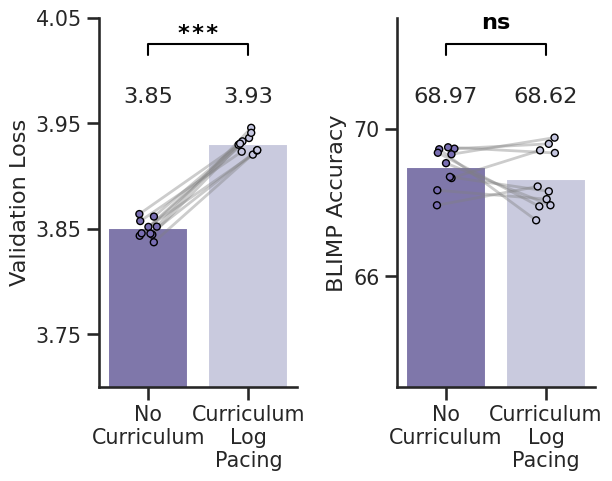

In [42]:
# rcParams.update(params_two_col)

curriculum_relevant_ids = {
6892222:"No Mask",
6689752:"Log Curriculum",
}
#Filter for curriculum true and babylm_full_bpe_8k and n_layer 6
#Or Curriculum False and babylm_full_bpe_8k and n_layer 6 and mask_type = Non, and echoic_memory = 1
with sns.axes_style("ticks"), sns.plotting_context("talk", font_scale=.9):
    curriculum_run_data_unfiltered = run_data_unfiltered[((run_data_unfiltered["curriculum_learning"]==True) & (run_data_unfiltered["dataset"] == "babylm_full_bpe_8k") & (run_data_unfiltered["n_layer"]==6)& (run_data_unfiltered["curriculum_type"] == "log") ) 
                                | ((run_data_unfiltered["curriculum_learning"]==False) & (run_data_unfiltered["dataset"] == "babylm_full_bpe_8k") & (run_data_unfiltered["n_layer"]==6) & (run_data_unfiltered["mask_type"] == "Non") & (run_data_unfiltered["echoic_memory"]==1))]

    #If seed is 1337, then filter for only relevant run ids, else filter for all 
    curriculum_run_data_unfiltered = curriculum_run_data_unfiltered[curriculum_run_data_unfiltered.apply(lambda x: x["run_id"] in curriculum_relevant_ids.keys() if x["seed"] == 1337 else True, axis=1)]   
    curriculum_run_data_unfiltered["condition"] = curriculum_run_data_unfiltered["output_folder_name"].apply(lambda x: "Log Curriculum" if "curr" in x else "No Curriculum")
    curriculum_run_data_unfiltered["condition"] = pd.Categorical(curriculum_run_data_unfiltered["condition"], categories=["No Curriculum", "Log Curriculum"], ordered=True)
    curriculum_run_data_unfiltered = curriculum_run_data_unfiltered.sort_values(by="condition")
    #Plot label order is order of the dictionary1
    curriculum_run_data_unfiltered = curriculum_run_data_unfiltered.merge(loss_data, on="run_id")
    #curriculum_run_data_unfiltered = curriculum_run_data_unfiltered.merge(rt_data, on="run_id")
    curriculum_run_data_unfiltered = curriculum_run_data_unfiltered.merge(blimp_data, on="run_id")
    #print(curriculum_run_data_unfiltered.columns)
    lowest_cur_val_loss_seed = run_data_unfiltered[((run_data_unfiltered["curriculum_learning"]==True) & (run_data_unfiltered["dataset"] == "babylm_full_bpe_8k") & (run_data_unfiltered["n_layer"]==6)& (run_data_unfiltered["curriculum_type"] == "log") )].merge(loss_data, on="run_id").sort_values(by="val_loss").head(1)["seed"].values[0]
    print("Lowest validation loss seed: ", lowest_cur_val_loss_seed)

    curriculum_run_data_unfiltered_rt = curriculum_run_data_unfiltered[["seed", "condition", "output_folder_name", "run_id"]].join(rt_subj_data[["run_id", "subject_id", "corr_surprisal"]].set_index("run_id"), on="run_id")
    #Number of rows
    print("Number of rows before filtering: ", curriculum_run_data_unfiltered_rt.shape[0])

    #Filter for only the lowest validation loss seed
    curriculum_run_data_unfiltered_rt = curriculum_run_data_unfiltered_rt[curriculum_run_data_unfiltered_rt["seed"] == lowest_cur_val_loss_seed]
    #curriculum_run_data_unfiltered_rt=  curriculum_run_data_unfiltered_rt[[]]
    print("Number of rows after filtering: ", curriculum_run_data_unfiltered_rt.shape[0])

    #Rename conditions as No Curriculum and Log Curriculum
    curriculum_run_data_unfiltered["condition"] = curriculum_run_data_unfiltered["condition"].apply(lambda x: "Curriculum\nLog\nPacing" if x == "Log Curriculum" else "No\nCurriculum")
    stats = []
    fig, ax = plt.subplots(1, 2) #, width_ratios=[2,2,2,1])
    #Add space between subplots
    fig.subplots_adjust(wspace=0.5)

    sns.barplot(data=curriculum_run_data_unfiltered, x="condition", y="val_loss", ax=ax[0], errorbar=None, palette="Purples_r", hue="condition")
    sns.stripplot(data=curriculum_run_data_unfiltered, x="condition", y="val_loss", ax=ax[0], alpha=1, edgecolor='black', linewidth=1, palette="Purples_r", hue="condition")

    connect_dots(ax[0])
    ax[0].set_ylim(3.7, 4)
    ax[0].set_yticks(np.arange(3.75, 4.1, 0.1))
    res = annotate_given_colid(ax[0], 0, 1, curriculum_run_data_unfiltered, 3.965, 0.005, "val_loss")
    stats.append({**{"pair_A":"No Curriculum", "pair_B":"Log Curriculum"} , **res})
    ax[0].set_ylabel("Validation Loss")
    ax[0].set_xlabel("")
    ax[0].set_xticklabels(labels = ax[0].get_xticklabels())
    #Annotate with values on top of the bars

    for p in ax[0].patches:
        patch_location = ax[0].get_ylim()[0] + (ax[0].get_ylim()[1] - ax[0].get_ylim()[0]) * 0.75
        ax[0].annotate(format(p.get_height(), '.2f'), (p.get_x() + p.get_width() / 2., patch_location),
                       ha='center', va='center', xytext=(0, 10), textcoords='offset points')
    #ax.xaxis.set_tick_params(rotation=90)

    sns.barplot(data=curriculum_run_data_unfiltered, x="condition", y="blimp_avg", ax=ax[1], errorbar=None, palette="Purples_r", hue="condition")
    sns.stripplot(data=curriculum_run_data_unfiltered, x="condition", y="blimp_avg", ax=ax[1], alpha=1, edgecolor='black', linewidth=1, palette="Purples_r", hue="condition")

    connect_dots(ax[1])
    ax[1].set_ylim(63,73)
    ax[1].set_yticks(np.arange(66, 74, 4))
    res1 = annotate_given_colid(ax[1], 1, 0, curriculum_run_data_unfiltered, 72.25, 0.1, "blimp_avg")
    stats.append({**{"pair_A":"No Curriculum", "pair_B":"Log Curriculum"} , **res1})
    ax[1].set_ylabel("BLIMP Accuracy")
    ax[1].set_xlabel("")
    ax[1].set_xticklabels( labels = ax[0].get_xticklabels())

    for p in ax[1].patches:
        patch_location = ax[1].get_ylim()[0] + (ax[1].get_ylim()[1] - ax[1].get_ylim()[0]) * 0.75
        ax[1].annotate(format(p.get_height(), '.2f'), (p.get_x() + p.get_width() / 2., patch_location),
                       ha='center', va='center', xytext=(0, 10), textcoords='offset points')
    #sns.stripplot(data=curriculum_run_data_unfiltered, x="condition", y="corr_surprisal", ax=ax[2])
    #connect_dots(ax[2])
    #

    # sns.barplot(data=curriculum_run_data_unfiltered_rt, x="condition", y="corr_surprisal", dodge=True, alpha=.5, ax=ax[2], errorbar=None)
    # sns.stripplot(data=curriculum_run_data_unfiltered_rt, x="condition", y="corr_surprisal", dodge=True, jitter=0.05, ax=ax[2], alpha=0.1, edgecolor='black', linewidth=1, size=2)


    # connect_dots(ax[2], alpha=.05)
    # ax[2].set_ylim(0,0.3) 
    # ax[2].set_yticks(np.arange(0, 0.31, 0.1))
    # res2 = annotate_given_colid(ax[2], 1, 0, curriculum_run_data_unfiltered_rt, 0.28, 0.002, "corr_surprisal", group_by = "subject_id")
    # stats.append({**{"pair_A":"No Curriculum", "pair_B":"Log Curriculum"} , **res2})
    # ax[2].set_ylabel("Corr. Surprisal")
    # ax[2].set_xlabel("")
    # ax[2].set_xticklabels( labels = ax[0].get_xticklabels())



    # curriculum_run_data_unfiltered_rt_delta = curriculum_run_data_unfiltered_rt[["condition","subject_id", "corr_surprisal"]].pivot(index="subject_id", columns="condition", values="corr_surprisal")
    # curriculum_run_data_unfiltered_rt_delta["delta"] = curriculum_run_data_unfiltered_rt_delta["Log Curriculum"] - curriculum_run_data_unfiltered_rt_delta["No Curriculum"]
    # sns.stripplot(data=curriculum_run_data_unfiltered_rt_delta, y="delta", ax=ax[3], size=2, alpha=0.5, edgecolor='black', linewidth=1, jitter=0.1)

    # ax[3].set_ylabel("Delta Corr. Surprisal")
    # ax[3].set_xlabel("")
    # ax[3].set_ylim(-0.05, 0.1)
    # ax[3].set_yticks(np.arange(-0.05, 0.099, 0.05))
    # for n, axs in enumerate(ax.flat):
    #     axs.text(-0.2, 1.1, string.ascii_uppercase[n], transform=axs.transAxes, size=15, weight='bold')
    sns.despine() #bottom=True, left=True)

    save_matplot_fig(fig, "Fig9_curriculum_effects_talkpaper.pdf", dpi=3000)
    print(pd.DataFrame(stats))

In [18]:
curriculum_run_data_unfiltered_rt

,seed,condition,output_folder_name,run_id,subject_id,corr_surprisal
6,6747,No\nCurriculum,out-babylm_full_bpe_8k-6x6-nomask-6892218_s6747,6892218,A117RW2F1MNBQ8,0.136453
6,6747,No\nCurriculum,out-babylm_full_bpe_8k-6x6-nomask-6892218_s6747,6892218,A11AUVZ4MCA7VU,0.150423
6,6747,No\nCurriculum,out-babylm_full_bpe_8k-6x6-nomask-6892218_s6747,6892218,A11GA4B4SEYK44,0.166429
6,6747,No\nCurriculum,out-babylm_full_bpe_8k-6x6-nomask-6892218_s6747,6892218,A11KMPAZSE5Q0Q,0.053275
6,6747,No\nCurriculum,out-babylm_full_bpe_8k-6x6-nomask-6892218_s6747,6892218,A127R5QI5OGBIK,0.125672
...,...,...,...,...,...,...
11,6747,Log\nCurriculum,out-babylm_full_bpe_8k-6x6-nomask-curr_log-704...,7047466,ASOBUAZ0IQYSJ,0.183921
11,6747,Log\nCurriculum,out-babylm_full_bpe_8k-6x6-nomask-curr_log-704...,7047466,AVG2BI8CS5YKX,0.135325
11,6747,Log\nCurriculum,out-babylm_full_bpe_8k-6x6-nomask-curr_log-704...,7047466,AWMGC78CSF6YL,0.170918
11,6747,Log\nCurriculum,out-babylm_full_bpe_8k-6x6-nomask-curr_log-704...,7047466,AWZ3AH7JH0DRO,0.128255


/tmp/ipykernel_476852/1629932896.py:314: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby('seed').apply(lambda x: x[x['condition']==list(conditional_map.values())[1]]["score"].values[0] - x[x['condition']==list(conditional_map.values())[0]]["score"].values[0])
/tmp/ipykernel_476852/1629932896.py:314: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_t

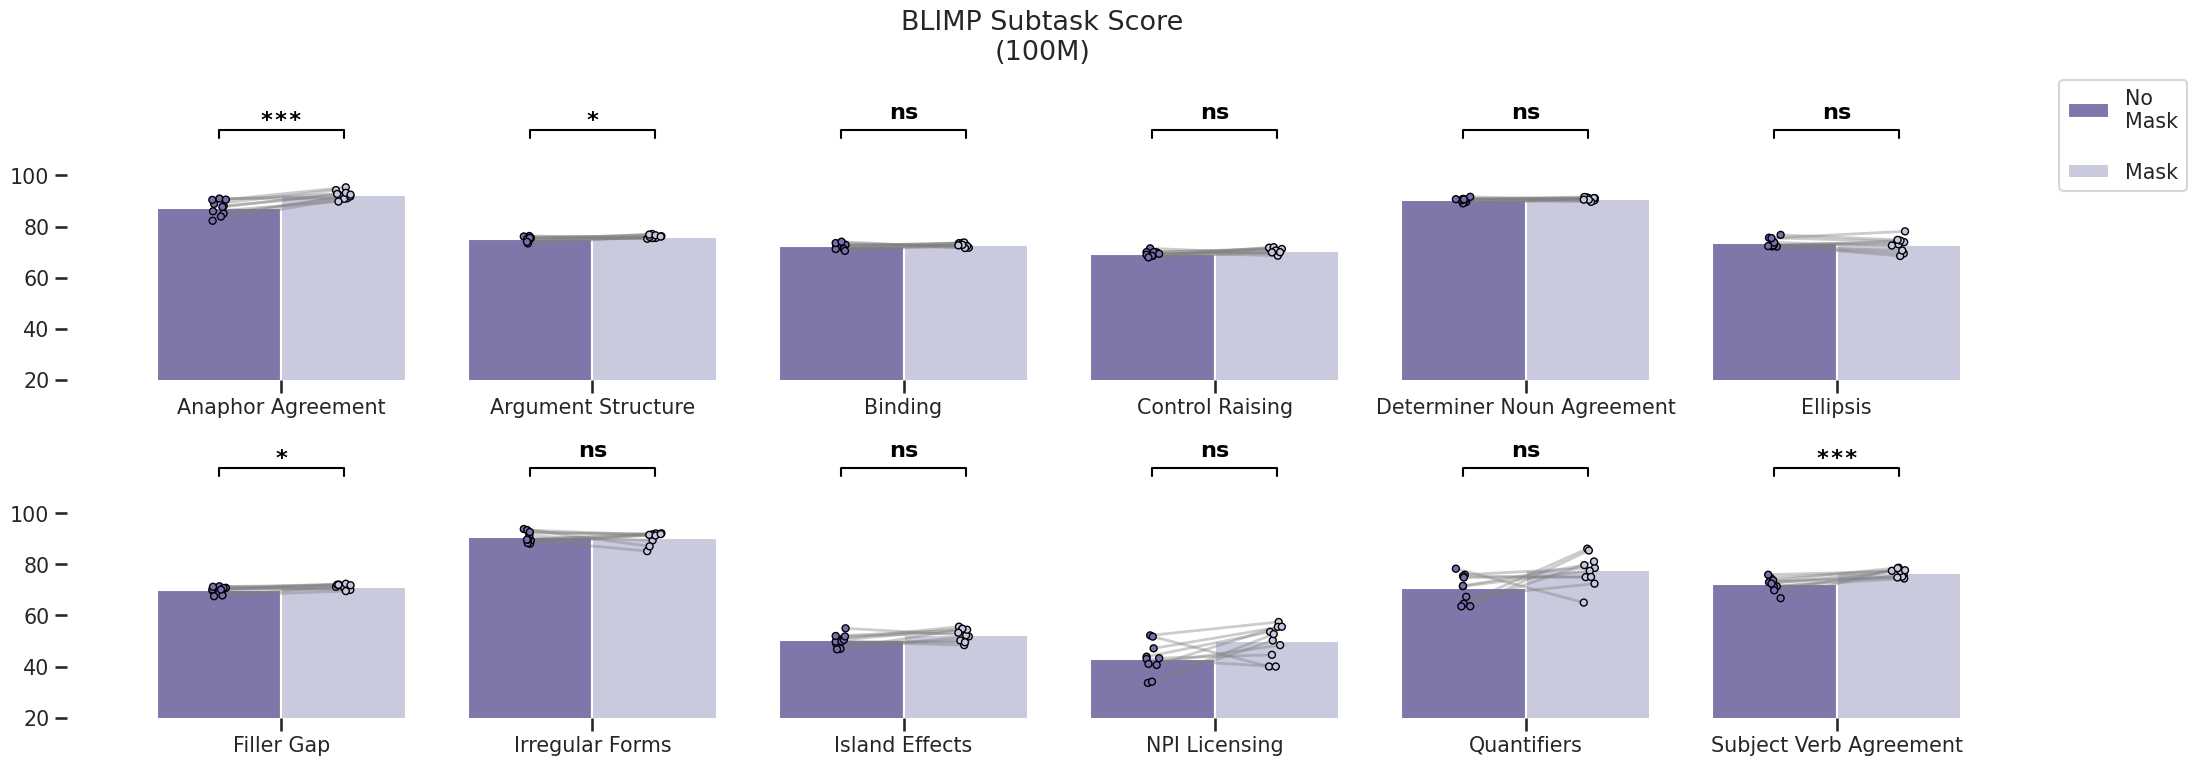

In [284]:

#Group by condition and get average of all BLIMP_avg and sort by that value
seed_df_100M_blimp_indv = seed_df_100M.merge(blimp_data, on="run_id", how="left")

#For this condition pair, plot all BLIMP tasks
#conditional_map = {"nomask_EM01": "No Mask", "ee002_EM10": "Exponential Mask\nEM10"}
#rcParams.update(params_two_col)
with sns.axes_style("ticks"), sns.plotting_context("talk", font_scale=.9):
    fig, ax = plt.subplots(2, 1)
    fig.set_size_inches(21, 7)
    fig.tight_layout()
    blimp_subtask_stats_test = []
    for row, axs in enumerate(ax):
        #Split blimp categories into 2 rows of subplots
        if row == 0:
            data_columns = [i[0] for i in blimp_categories[:6]] + ["condition", "seed"]
        else:
            data_columns = [i[0] for i in blimp_categories[6:12]] + ["condition", "seed"]

        ax = axs
        plot_data = seed_df_100M_blimp_indv[data_columns][seed_df_100M["condition"].isin(["No\nMask", "Mask"])]
        #plot_data["condition"] = pd.Categorical(plot_data["condition"], categories=["nomask_EM01", "ee002_EM10"], ordered=True)
        #plot_data["condition"] = plot_data["condition"].map(condition_triplet_map)
        
        #Pivot blimp_categories into rows 
        plot_data = pd.melt(plot_data, id_vars=["condition", "seed"], value_vars=[k for k in data_columns[:-2]                                                                                ]).rename(columns={"variable": "blimp_task", "value": "score"})
        
        
        sns.barplot(data=plot_data, x="blimp_task", y="score" , hue="condition",
                    dodge=True, ax=ax, errorbar=None, palette="Purples_r")
        
        #Add value labels to each bar slighly above the bar
        
        # for p in ax.patches:
        #     ax.annotate(format(p.get_height(), '.2f'), (p.get_x() + p.get_width() / 2., p.get_height()+5.5),
        #                 ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points')
        
        sns.stripplot(data=plot_data, x="blimp_task", y="score", hue="condition", dodge=True, jitter=0.05, ax=ax, alpha=1, edgecolor='black', linewidth=1, palette="Purples_r")
        connect_dots_ib(ax)
        
        #set title for each subplot but remove \n from mapping
        #ax.xaxis.set_tick_params(rotation=45)
        ax.set_ylim(35, 125)
        #Remove legend for each subplot
        ax.get_legend().remove()
        ax.set_xlabel("")
        ax.set_ylabel("")

        #Set ticks such that they are visible only below 100 
        ax.set_yticks(ax.get_yticks()[ax.get_yticks()<=100])
        for k in range(6):
            res = annotate_given_colid_ib(ax, k, plot_data, 103, 2, {x: x for x in ["No\nMask", "Mask"]})
            blimp_subtask_stats_test.append({**{"blimp_task": blimp_name_map[data_columns[k]],
                                                "pair_A":"nomask_EM01", "pair_B":"ee002_EM10"} , **res})
            
        
        #print(ax.get_xticklabels())
        ax.set_xticklabels([blimp_name_map[i.get_text()] for i in ax.get_xticklabels()])
        sns.despine(bottom=True, left=True)
    handles, labels = ax.get_legend_handles_labels()
    #Legend position is set to top right and overlapping with the plot
    fig.legend(handles[:2], labels[:2], loc='right', bbox_to_anchor=(1.05, 0.92), labelspacing=1.5)
    #fig.supylabel("BLIMP Score")
    #rint(pd.DataFrame(blimp_subtask_stats_test))
    #save_matplot_fig(fig, "Fig6_blimp_subtasks.pdf", dpi=3000)
    fig.suptitle("BLIMP Subtask Score\n(100M)", y = 1.1)

    save_matplot_fig(fig, "Fig9_blimp_subtask_100M.png", dpi=1000)
    save_matplot_fig(fig, "Fig9_blimp_subtask_100M.pdf", dpi=3000)

Comparing No
Mask and Mask
{'mean                    ': -5.01022494887525, '95%_CI around mean      ': (-6.50817995910018, -3.445679959100169), 'bootstrap-t-test p_value': 'p=0.0004'}
Old y, h 103 2
Y lim values (20.0, 125.0)
New y, h 114.5 3.15


/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])


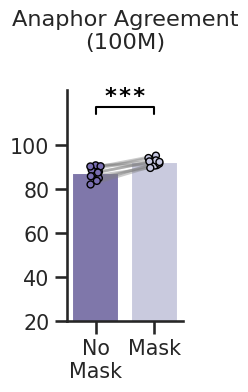

Comparing No
Mask and Mask
{'mean                    ': -0.9832686711929994, '95%_CI around mean      ': (-1.7204170708050313, -0.2509396217264676), 'bootstrap-t-test p_value': 'p=0.0312'}
Old y, h 103 2
Y lim values (20.0, 125.0)
New y, h 114.5 3.15


/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])


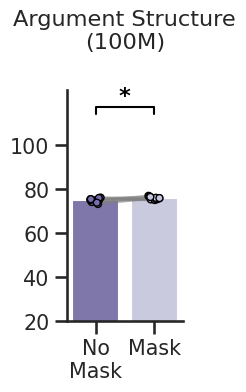

Comparing No
Mask and Mask
{'mean                    ': -0.4021964974769915, '95%_CI around mean      ': (-1.323834965865231, 0.5624814485010433), 'bootstrap-t-test p_value': 'p=0.4486'}
Old y, h 103 2
Y lim values (20.0, 125.0)
New y, h 114.5 3.15


/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])


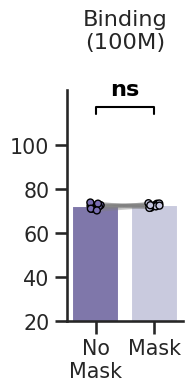

Comparing No
Mask and Mask
{'mean                    ': -1.2372956252761695, '95%_CI around mean      ': (-2.2337604949182306, -0.12593901900131213), 'bootstrap-t-test p_value': 'p=0.134'}
Old y, h 103 2
Y lim values (20.0, 125.0)
New y, h 114.5 3.15


/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])


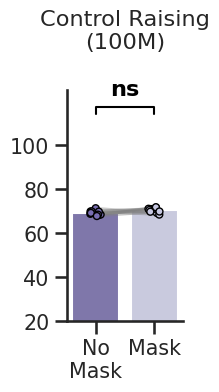

Comparing No
Mask and Mask
{'mean                    ': -0.3659506762132125, '95%_CI around mean      ': (-0.8977061787324503, 0.185627154600897), 'bootstrap-t-test p_value': 'p=0.2874'}
Old y, h 103 2
Y lim values (20.0, 125.0)
New y, h 114.5 3.15


/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])


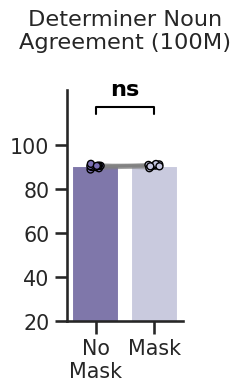

Comparing No
Mask and Mask
{'mean                    ': 0.6639722863741497, '95%_CI around mean      ': (-0.6466512702078319, 1.9284064665127119), 'bootstrap-t-test p_value': 'p=0.373'}
Old y, h 103 2
Y lim values (20.0, 125.0)
New y, h 114.5 3.15


/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])


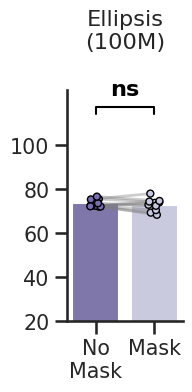

Comparing No
Mask and Mask
{'mean                    ': -1.2713974478680385, '95%_CI around mean      ': (-2.0292950513538583, -0.5197634609399586), 'bootstrap-t-test p_value': 'p=0.0278'}
Old y, h 103 2
Y lim values (20.0, 125.0)
New y, h 114.5 3.15


/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])


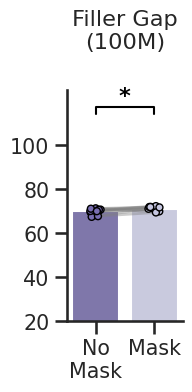

Comparing No
Mask and Mask
{'mean                    ': 0.4580152671755684, '95%_CI around mean      ': (-1.5013994910941562, 2.4885496183205986), 'bootstrap-t-test p_value': 'p=0.6612'}
Old y, h 103 2
Y lim values (20.0, 125.0)
New y, h 114.5 3.15


/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])


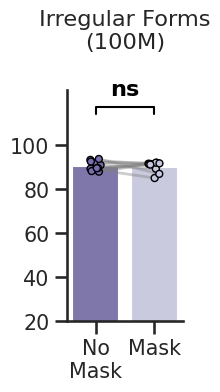

Comparing No
Mask and Mask
{'mean                    ': -2.2458893871449996, '95%_CI around mean      ': (-4.103139013452919, -0.3550074738415582), 'bootstrap-t-test p_value': 'p=0.0576'}
Old y, h 103 2
Y lim values (20.0, 125.0)
New y, h 114.5 3.15


/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])


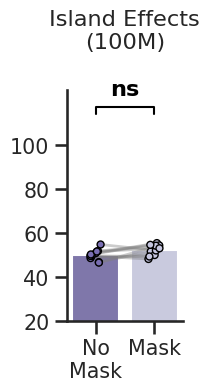

Comparing No
Mask and Mask
{'mean                    ': -6.762830245976299, '95%_CI around mean      ': (-12.031733981172168, -0.904760097175793), 'bootstrap-t-test p_value': 'p=0.0934'}
Old y, h 103 2
Y lim values (20.0, 125.0)
New y, h 114.5 3.15


/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])


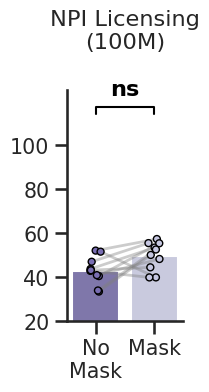

Comparing No
Mask and Mask
{'mean                    ': -6.944873776403897, '95%_CI around mean      ': (-13.248583204533741, -0.3399665121071535), 'bootstrap-t-test p_value': 'p=0.0686'}
Old y, h 103 2
Y lim values (20.0, 125.0)
New y, h 114.5 3.15


/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])


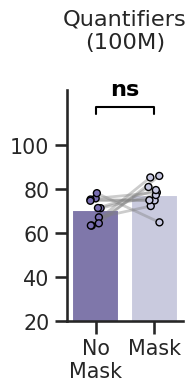

Comparing No
Mask and Mask
{'mean                    ': -4.482384823848223, '95%_CI around mean      ': (-6.547470641373052, -2.8075880758807426), 'bootstrap-t-test p_value': 'p < 0.0001'}
Old y, h 103 2
Y lim values (20.0, 125.0)
New y, h 114.5 3.15


/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])


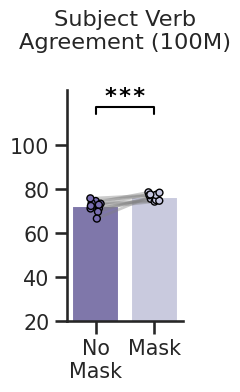

                   blimp_task       pair_A      pair_B  \
0           Anaphor Agreement  nomask_EM01  ee002_EM10   
1          Argument Structure  nomask_EM01  ee002_EM10   
2                     Binding  nomask_EM01  ee002_EM10   
3             Control Raising  nomask_EM01  ee002_EM10   
4   Determiner Noun Agreement  nomask_EM01  ee002_EM10   
5                    Ellipsis  nomask_EM01  ee002_EM10   
6                  Filler Gap  nomask_EM01  ee002_EM10   
7             Irregular Forms  nomask_EM01  ee002_EM10   
8              Island Effects  nomask_EM01  ee002_EM10   
9               NPI Licensing  nomask_EM01  ee002_EM10   
10                Quantifiers  nomask_EM01  ee002_EM10   
11     Subject Verb Agreement  nomask_EM01  ee002_EM10   

    mean                                         95%_CI around mean        \
0                  -5.010225      (-6.50817995910018, -3.445679959100169)   
1                  -0.983269   (-1.7204170708050313, -0.2509396217264676)   
2             

In [285]:
# Group by condition and get average of all BLIMP_avg and sort by that value
seed_df_100M_blimp_indv = seed_df_100M.merge(blimp_data, on="run_id", how="left")

# For this condition pair, plot all BLIMP tasks
with sns.axes_style("ticks"), sns.plotting_context("talk", font_scale=.9):
    blimp_subtask_stats_test = []
    for i, (blimp_task, blimp_div) in enumerate(blimp_categories):
        if blimp_div == "supplement":
            continue
        fig, ax = plt.subplots(1, 1, figsize=(1.5, 3))
        #fig.set_size_inches(10, 5)
        
        
        
        data_columns = [blimp_task, "condition", "seed"]
        plot_data = seed_df_100M_blimp_indv[data_columns][seed_df_100M["condition"].isin(["No\nMask", "Mask"])]
        
        plot_data = pd.melt(plot_data, id_vars=["condition", "seed"], value_vars=[blimp_task]).rename(columns={"variable": "blimp_task", "value": "score"})
        plot_data["condition"] = plot_data["condition"].map({x: x for x in ["No\nMask", "Mask"]})

        
        #print(plot_data)
        sns.barplot(data=plot_data, x="condition", y="score", hue="condition", ax=ax, errorbar=None, palette="Purples_r")
        
        # for p in ax.patches:
        #     ax.annotate(format(p.get_height(), '.2f'), (p.get_x() + p.get_width() / 2., p.get_height() + 5.5),
        #                 ha='center', va='center', xytext=(0, 10), textcoords='offset points')
        
        sns.stripplot(data=plot_data, x="condition", y="score", hue="condition", ax=ax, alpha=1, edgecolor='black', linewidth=1, palette="Purples_r")
        connect_dots(ax)
        
        ax.set_ylim(35, 125)
        #ax.get_legend().remove()
        #ax.set_xlabel(blimp_name_map[blimp_task].replace(" ", "\n"), labelpad=10)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_yticks(ax.get_yticks()[ax.get_yticks() <= 100])
        
        res = annotate_given_colid(ax, 0, 1, plot_data, 103, 2, "score")
        blimp_subtask_stats_test.append({**{"blimp_task": blimp_name_map[blimp_task], "pair_A": "nomask_EM01", "pair_B": "ee002_EM10"}, **res})
        
        #ax.set_xticklabels([blimp_name_map[i.get_text()] for i in ax.get_xticklabels()])
        sns.despine()
        
        title_str = blimp_name_map[blimp_task]
        
        #Break and join the title string into 2 lines
        if len(title_str.split()) > 2:
            title_str = " ".join(title_str.split()[:2]) + "\n" + " ".join(title_str.split()[2:]) + " (100M)"
        else:
            title_str = title_str + "\n(100M)"

        plt.title(title_str, pad=30)
        plt.show()
        save_name = blimp_name_map[blimp_task].replace("\n", " ")
        save_matplot_fig(fig, f"Fig9_blimp_subtask_{blimp_task}_100M.png", dpi=1000, folders_path="figure_9_100M_sep")
        save_matplot_fig(fig, f"Fig9_blimp_subtask_{blimp_task}_100M.pdf", dpi=3000, folders_path="figure_9_100M_sep")    
    print(pd.DataFrame(blimp_subtask_stats_test))
    # save_matplot_fig(fig, "Fig6_blimp_subtasks.pdf", dpi=3000)


In [242]:
#Since only 5 seed values are there for all different settings - 42, 466, 616, 1337, 2347


seed_df_masks_100M = run_data_unfiltered[
    (run_data_unfiltered["curriculum_learning"] == False) & (run_data_unfiltered["dataset"] == "babylm_full_bpe_100M_8k") & 
    (run_data_unfiltered["n_layer"] == 6) & (run_data_unfiltered["batch_size"] == 256) & (run_data_unfiltered["num_iterations"] == 44000) 
    #& (run_data_unfiltered["seed"].isin([42, 466, 616, 1337, 2347]))
    & (((run_data_unfiltered["mask_type"].isin(["Non"]))  & (run_data_unfiltered["run_id"] != 5496427)) 
        | ((run_data_unfiltered["mask_type"].isin(["exponential_new"])) & (run_data_unfiltered["mask_decay_rate"].isin([0.5,1,2,3,4])) & (run_data_unfiltered["echoic_memory"].isin([1,5,10]))))
][["run_id", "output_folder_name", "n_layer", "n_head", "block_size", "n_embd", "batch_size", "learning_rate", "mask_type", "mask_decay_rate", "echoic_memory", "dataset", "seed"]].reset_index(drop=True)


seed_df_masks_100M = seed_df_masks_100M.sort_values(by=["mask_type", "mask_decay_rate", "echoic_memory", "seed"]).reset_index(drop=True)

seed_df_masks_100M["condition"] = seed_df_masks_100M["mask_type"].apply(lambda x: "Mask" if x != "Non" else "No\nMask")
seed_df_masks_100M["x_condition"] = seed_df_masks_100M["condition"] + " " + seed_df_masks_100M["mask_decay_rate"].astype(str).apply(lambda x: "" if x == "0.0" else x) 
seed_df_masks_100M["x_condition"] = seed_df_masks_100M["x_condition"].apply(lambda x: x.strip())

seed_df_masks_100M["condition"] = seed_df_masks_100M["condition"] + "\nEM" + seed_df_masks_100M["echoic_memory"].astype(str).str.zfill(2)
seed_df_masks_100M = seed_df_masks_100M.sort_values(by=["seed", "condition"]).reset_index(drop=True)

seed_df_masks_100M = seed_df_masks_100M.merge(loss_data[['run_id', 'val_loss', 'train_loss']], on="run_id", how="left")


seed_df_masks_100M["echoic_memory_flag"] = seed_df_masks_100M["echoic_memory"].apply(lambda x: False if x == 1 else True)

seed_df_masks_100M.sort_values(by=['x_condition', 'echoic_memory', 'seed'], inplace=True)
seed_df_masks_100M.reset_index(drop=True, inplace=True)

seed_df_masks_100M

,run_id,output_folder_name,n_layer,n_head,block_size,n_embd,batch_size,learning_rate,mask_type,mask_decay_rate,echoic_memory,dataset,seed,condition,x_condition,val_loss,train_loss,echoic_memory_flag
0,8178952,out-babylm_full_bpe_100M_8k-6x6-mask_ee0p5_em1...,6,6,256,384,256.0,0.00141,exponential_new,0.5,10,babylm_full_bpe_100M_8k,9,Mask\nEM10,Mask 0.5,3.326908,3.237979,True
1,8175589,out-babylm_full_bpe_100M_8k-6x6-mask_ee0p5_em1...,6,6,256,384,256.0,0.00141,exponential_new,0.5,10,babylm_full_bpe_100M_8k,42,Mask\nEM10,Mask 0.5,3.322266,3.230961,True
2,8182744,out-babylm_full_bpe_100M_8k-6x6-mask_ee0p5_em1...,6,6,256,384,256.0,0.00141,exponential_new,0.5,10,babylm_full_bpe_100M_8k,466,Mask\nEM10,Mask 0.5,3.318472,3.227038,True
3,8178972,out-babylm_full_bpe_100M_8k-6x6-mask_ee0p5_em1...,6,6,256,384,256.0,0.00141,exponential_new,0.5,10,babylm_full_bpe_100M_8k,616,Mask\nEM10,Mask 0.5,3.321950,3.233618,True
4,8182743,out-babylm_full_bpe_100M_8k-6x6-mask_ee0p5_em1...,6,6,256,384,256.0,0.00141,exponential_new,0.5,10,babylm_full_bpe_100M_8k,869,Mask\nEM10,Mask 0.5,3.324234,3.238602,True
5,8173546,out-babylm_full_bpe_100M_8k-6x6-mask_ee0p5_em1...,6,6,256,384,256.0,0.00141,exponential_new,0.5,10,babylm_full_bpe_100M_8k,1337,Mask\nEM10,Mask 0.5,3.328177,3.240427,True
6,8178694,out-babylm_full_bpe_100M_8k-6x6-mask_ee0p5_em1...,6,6,256,384,256.0,0.00141,exponential_new,0.5,10,babylm_full_bpe_100M_8k,2347,Mask\nEM10,Mask 0.5,3.323636,3.234818,True
7,8180899,out-babylm_full_bpe_100M_8k-6x6-mask_ee0p5_em1...,6,6,256,384,256.0,0.00141,exponential_new,0.5,10,babylm_full_bpe_100M_8k,6747,Mask\nEM10,Mask 0.5,3.321743,3.231329,True
8,8182745,out-babylm_full_bpe_100M_8k-6x6-mask_ee0p5_em1...,6,6,256,384,256.0,0.00141,exponential_new,0.5,10,babylm_full_bpe_100M_8k,11111,Mask\nEM10,Mask 0.5,3.320262,3.231371,True
9,8180897,out-babylm_full_bpe_100M_8k-6x6-mask_ee0p5_em1...,6,6,256,384,256.0,0.00141,exponential_new,0.5,10,babylm_full_bpe_100M_8k,46674,Mask\nEM10,Mask 0.5,3.323061,3.234438,True


2
3
[10  1]
['Mask 0.5' 'Mask 2.0' 'Mask 4.0']


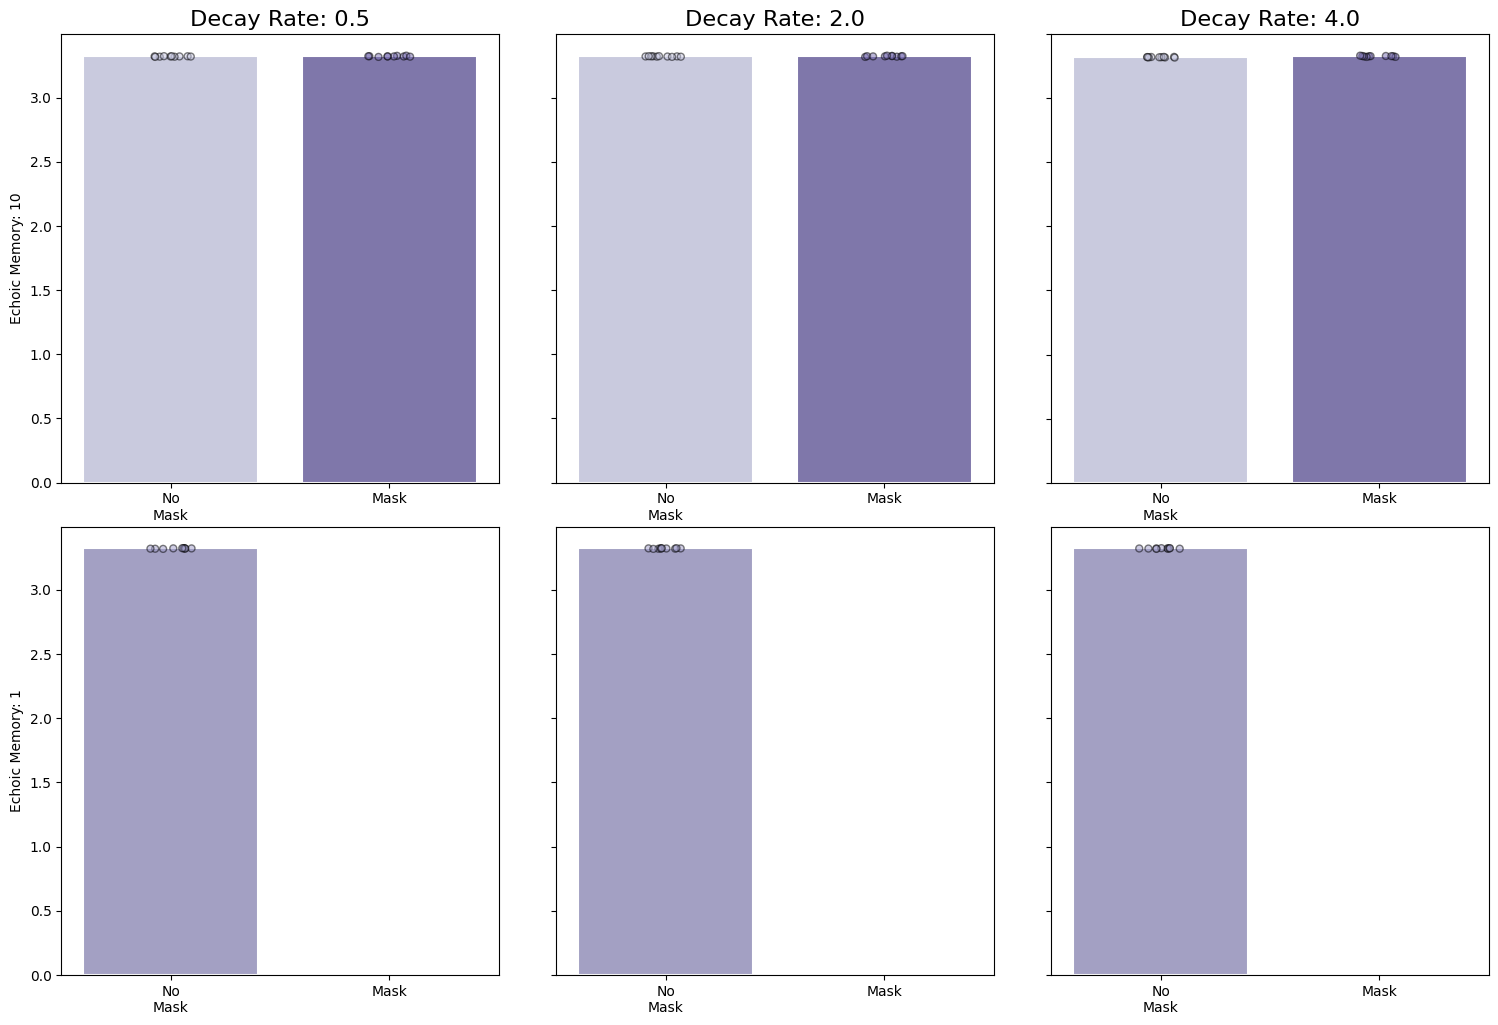

In [243]:
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
fig.tight_layout()
print(len(seed_df_masks_100M['echoic_memory'].unique()))
print(len(seed_df_masks_100M[seed_df_masks_100M['x_condition'] != 'No\nMask']['x_condition'].unique()))
print(seed_df_masks_100M['echoic_memory'].unique())
print(seed_df_masks_100M[seed_df_masks_100M['x_condition'] != 'No\nMask']['x_condition'].unique())
with sns.axes_style("ticks"), sns.plotting_context("talk", font_scale=.9):
    for i, em in enumerate(seed_df_masks_100M['echoic_memory'].unique()):
        for j, x_cond in enumerate(seed_df_masks_100M[seed_df_masks_100M['x_condition'] != 'No\nMask']['x_condition'].unique()):
            
            barplot_data = seed_df_masks_100M[(seed_df_masks_100M['echoic_memory'] == em) & (seed_df_masks_100M['x_condition'] == x_cond) | (seed_df_masks_100M['echoic_memory'] == 1) & (seed_df_masks_100M['x_condition'] == 'No\nMask')]
            barplot_data = barplot_data.sort_values(by='seed')
            barplot_data["x_condition"] = pd.Categorical(barplot_data["x_condition"], categories=["No\nMask", x_cond], ordered=True)

            stripplot_data = seed_df_masks_100M[(seed_df_masks_100M['echoic_memory'] == em) & (seed_df_masks_100M['x_condition'] == x_cond) | (seed_df_masks_100M['echoic_memory'] == 1) & (seed_df_masks_100M['x_condition'] == 'No\nMask')]
            stripplot_data = stripplot_data.sort_values(by='seed')
            stripplot_data["x_condition"] = pd.Categorical(stripplot_data["x_condition"], categories=["No\nMask", x_cond], ordered=True)

            barplot_data["x_condition"] = barplot_data["x_condition"].apply(lambda x: {x_cond: "Mask"}[x] if x != "No\nMask" else x)
            stripplot_data["x_condition"] = stripplot_data["x_condition"].apply(lambda x: {x_cond: "Mask"}[x] if x != "No\nMask" else x)
            
            sns.barplot(data=barplot_data, x='x_condition', y='val_loss', ax=axs[i, j], errorbar=None, palette="Purples_r", hue='condition')
            sns.stripplot(data=stripplot_data, x='x_condition', y='val_loss', ax=axs[i, j], alpha=0.5, palette="Purples_r", hue='condition', edgecolor='black', linewidth=1)
            
            if i == 0:
                axs[i, j].set_title(f"Decay Rate: {x_cond.split(' ')[1]}")

            #axs[i, j].set_ylim(3.75, 4)
            axs[i,j].set_xlabel('')
            axs[i,j].set_ylabel('')
            #connect_dots(axs[i, j])
            
            if j != 0:
                axs[i, j].set_yticklabels([])
            else:
                axs[i, j].set_ylabel(f"Echoic Memory: {em}")
            
            axs[i, j].legend().remove()
            # for p in axs[i, j].patches:
            #     axs[i, j].annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()+0.025), ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=8)
